# Explaratory Data Analysis of Steam Multimodal Dataset 2025

In this notebook, I present a comprehensive overview of the dataset with regard of the defined business goals:
> *Identify the characteristics of developers (based on their application portfolios) that correlate with having at least one published game with publishers in the top 100 by published volume on Steam.*

> *Create a scoring system that ranks emerging developers (first releasewithin 3 years) according to similarity to the successful partnership patterns identified.*

The findings are further reported in the CRISP-DM report section related to Data Understanding.

The notebook has the following contents:

1. Dataset Collection
2. Business Understanding -> Data Understanding

    2.1. First Business Objective

    2.2. Second Business Objective

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid")

# Dataset Collection

In [ ]:
import os
import pandas as pd
import kagglehub

# Download the dataset and get its root directory
dataset_root = kagglehub.dataset_download("crainbramp/steam-dataset-2025-multi-modal-gaming-analytics")

# Build the path to the folder that actually contains the CSV files
csv_dir = os.path.join(
    dataset_root,
    "steam_dataset_2025_csv_package_v1",
    "steam_dataset_2025_csv"
)

In [ ]:
# Read all CSV files
df_apps = pd.read_csv(os.path.join(csv_dir, "applications.csv"))
df_genres = pd.read_csv(os.path.join(csv_dir, "genres.csv"))
df_pub = pd.read_csv(os.path.join(csv_dir, "publishers.csv"))
df_dev = pd.read_csv(os.path.join(csv_dir, "developers.csv"))
df_reviews = pd.read_csv(os.path.join(csv_dir, "reviews.csv"))
df_cat = pd.read_csv(os.path.join(csv_dir, "categories.csv"))

df_app_genres = pd.read_csv(os.path.join(csv_dir, "application_genres.csv"))
df_app_pub = pd.read_csv(os.path.join(csv_dir, "application_publishers.csv"))
df_app_dev = pd.read_csv(os.path.join(csv_dir, "application_developers.csv"))
df_app_cat = pd.read_csv(os.path.join(csv_dir, "application_categories.csv"))

## Descriptive Analysis

### Core Tables

In [5]:
df_apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239664 entries, 0 to 239663
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   appid                  239664 non-null  int64  
 1   name                   239660 non-null  object 
 2   type                   236997 non-null  object 
 3   is_free                239664 non-null  bool   
 4   release_date           202809 non-null  object 
 5   required_age           239664 non-null  object 
 6   short_description      224171 non-null  object 
 7   supported_languages    222006 non-null  object 
 8   header_image           239664 non-null  object 
 9   background             239664 non-null  object 
 10  metacritic_score       5299 non-null    float64
 11  recommendations_total  22560 non-null   float64
 12  mat_supports_windows   239664 non-null  bool   
 13  mat_supports_mac       239664 non-null  bool   
 14  mat_supports_linux     239664 non-nu

In [6]:
df_pub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85699 entries, 0 to 85698
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      85699 non-null  int64 
 1   name    85694 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [7]:
df_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101226 entries, 0 to 101225
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      101226 non-null  int64 
 1   name    101221 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.5+ MB


In [8]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048148 entries, 0 to 1048147
Data columns (total 23 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   recommendationid                1048148 non-null  int64  
 1   appid                           1048148 non-null  int64  
 2   author_steamid                  1048148 non-null  int64  
 3   author_num_games_owned          1048148 non-null  int64  
 4   author_num_reviews              1048148 non-null  int64  
 5   author_playtime_forever         1048145 non-null  float64
 6   author_playtime_last_two_weeks  1048145 non-null  float64
 7   author_playtime_at_review       869291 non-null   float64
 8   author_last_played              1048145 non-null  float64
 9   language                        1048148 non-null  object 
 10  review_text                     1047369 non-null  object 
 11  timestamp_created               1048148 non-null  int64  
 12  

### Junction Tables

In [9]:
df_app_pub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223048 entries, 0 to 223047
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   appid         223048 non-null  int64
 1   publisher_id  223048 non-null  int64
dtypes: int64(2)
memory usage: 3.4 MB


In [10]:
df_app_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250817 entries, 0 to 250816
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   appid         250817 non-null  int64
 1   developer_id  250817 non-null  int64
dtypes: int64(2)
memory usage: 3.8 MB


# Business Understanding -> Data Understanding

## First Business Objective

**Business objective**: 

*Identify the characteristics of developers (based on their application portfolios and partnership histories) that correlate with having at least one published game with publishers in the top $p$ by published volume on Steam.*

EDA Steps:
- What $p$ should be selected to cover substantial volume on Steam?
- How publishers and developers are represented?
- How useful are reviews in terms of describing a developer?
- What other features are insightful about a developer?

### Game Focus Exploration

Since we focus on games published on Steam, we sort out application with `type=game`:

In [11]:
df_games = df_apps[df_apps['type'] == 'game']

print(f"The proportion of games on Steam is {
    100 * round(len(df_games) / len(df_apps), 2)
}%")

The proportion of games on Steam is 63.0%


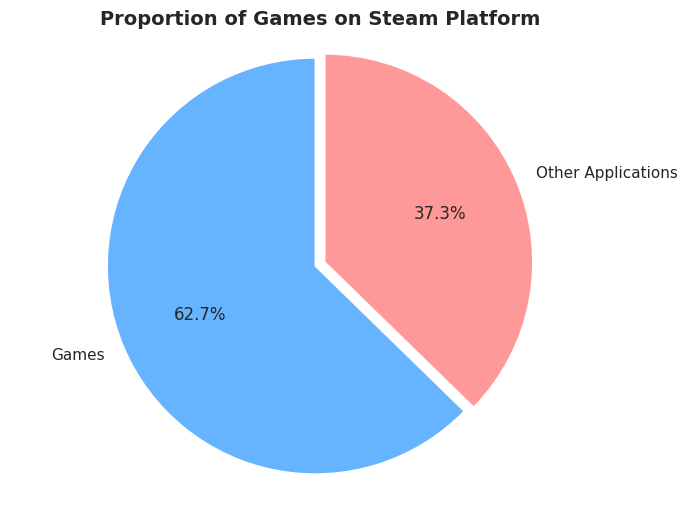

The proportion of games on Steam is 63.0%
Total applications: 239,664
Games: 150,279
Other applications: 89,385


In [12]:
# Calculate counts
game_count = len(df_apps[df_apps['type'] == 'game'])
non_game_count = len(df_apps) - game_count

# Create pie chart
plt.figure(figsize=(8, 6))
plt.pie([game_count, non_game_count], 
        labels=['Games', 'Other Applications'],
        autopct='%1.1f%%',
        colors=['#66b3ff', '#ff9999'],
        startangle=90,
        explode=(0.05, 0))
plt.title('Proportion of Games on Steam Platform', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

# Print the proportion (your original calculation)
print(f"The proportion of games on Steam is {100 * round(game_count / len(df_apps), 2)}%")
print(f"Total applications: {len(df_apps):,}")
print(f"Games: {game_count:,}")
print(f"Other applications: {non_game_count:,}")

Additionally, the games published within last 10 years will be considered `release_date.year` $\in [2015, 2025]$.

In [13]:
df_games['release_date'] = pd.to_datetime(df_games['release_date'], errors='coerce')
df_games_filtered = df_games[
    (df_games['release_date'].dt.year >= 2015) & (df_games['release_date'].dt.year <= 2025)
]

print(f"The proportion of games published between 2025 and 2025 on Steam is {
    100 * round(len(df_games_filtered) / len(df_games), 2)
}%")

The proportion of games published between 2025 and 2025 on Steam is 75.0%


/tmp/ipykernel_17/384831558.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_games['release_date'] = pd.to_datetime(df_games['release_date'], errors='coerce')


In [14]:
df_games = df_games_filtered.copy()

In [15]:
df_game_genres = df_app_genres[df_app_genres['appid'].isin(df_games['appid'])]
df_game_pub = df_app_pub[df_app_pub['appid'].isin(df_games['appid'])]
df_game_dev = df_app_dev[df_app_dev['appid'].isin(df_games['appid'])]
df_game_cat = df_app_cat[df_app_cat['appid'].isin(df_games['appid'])]

### Exploring Top $p$ Publishers by Published Volume on Steam

#### Merge tables for publishers and developers

In [16]:
df_pub_dev = pd.merge(
    df_game_pub.merge(
        df_pub,
        left_on='publisher_id',
        right_on='id'
    ).drop(columns=['id']).rename(columns={'name': 'publisher_name'}),

    df_game_dev.merge(
        df_dev,
        left_on='developer_id',
        right_on='id'
    ).drop(columns=['id']).rename(columns={'name': 'developer_name'}),

    on='appid'
)

In [17]:
df_pub_dev.head()

,appid,publisher_id,publisher_name,developer_id,developer_name
0,1313,29233,Nightdive Studios,6118,Ritual Entertainment
1,1313,29233,Nightdive Studios,34532,Nightdive Studios
2,7800,11073,Aspyr,13064,Aspyr
3,8980,28257,2K,21806,Gearbox Software
4,11550,80967,THQ Nordic,68436,Free Radical Design


#### Sort publishers by published volume:

In [18]:
grouped_by_publisher = df_pub_dev.groupby('publisher_name')

ranking_by_volume = grouped_by_publisher['appid'].nunique().sort_values(ascending=False)

ranking_by_volume.head(10)

publisher_name
Big Fish Games     529
8floor             268
EroticGamesClub    207
PlayWay S.A.       193
Kagura Games       183
Hede               181
HH-Games           181
Conglomerate 5     172
Laush Studio       171
Choice of Games    166
Name: appid, dtype: int64

#### Calculate proportion of volume w.r.t. total published volume on Steam:

In [19]:
total_volume = ranking_by_volume.sum()

percent_volume = (ranking_by_volume / total_volume)

percent_volume.head(10)

publisher_name
Big Fish Games    0.00
8floor            0.00
EroticGamesClub   0.00
PlayWay S.A.      0.00
Kagura Games      0.00
Hede              0.00
HH-Games          0.00
Conglomerate 5    0.00
Laush Studio      0.00
Choice of Games   0.00
Name: appid, dtype: float64

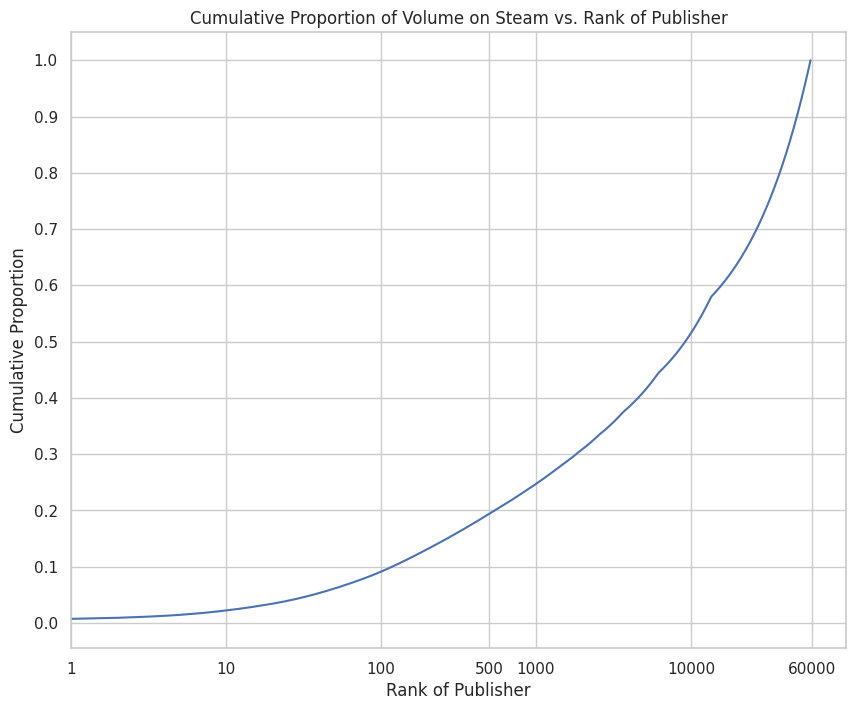

In [20]:
plt.figure(figsize=(10, 8))
plt.title("Cumulative Proportion of Volume on Steam vs. Rank of Publisher")

plt.xlabel("Rank of Publisher")
plt.ylabel("Cumulative Proportion")

plt.xscale('log')

plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks([1, 10, 100, 500, 1000, 10_000, 60_000])
plt.xlim([1, 100_000])

plt.gca().get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

plt.plot(range(len(percent_volume)), np.cumsum(percent_volume))

In [21]:
round(percent_volume.head(100).sum(), 3)

np.float64(0.091)

#### Filtration Criteria

**Ranking only by published volume is not sufficient for finding major publishers: partnerships should be considered as well**

In [22]:
ranking_by_partnerships = grouped_by_publisher['developer_id'].nunique().sort_values(ascending=False)
ranking_by_partnerships.head(10)

publisher_name
Plug In Digital                    117
Kagura Games                       114
DigiPen Institute of Technology    111
indie.io                           107
PlayWay S.A.                        98
Conglomerate 5                      97
Devolver Digital                    94
PLAYISM                             93
Gamirror Games                      89
Sekai Project                       87
Name: developer_id, dtype: int64

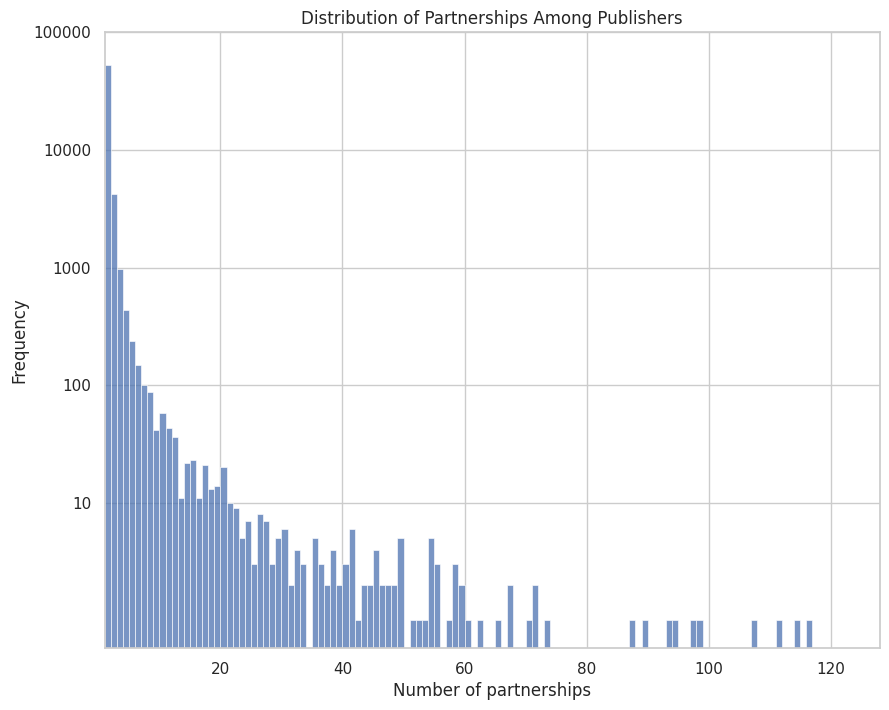

In [23]:
plt.figure(figsize=(10, 8))
plt.title('Distribution of Partnerships Among Publishers')

sns.histplot(ranking_by_partnerships, binwidth=1)

plt.yscale('log')

plt.yticks([10, 100, 1000, 10000, 100_000])
plt.xlim([1, 128])

plt.gca().get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
plt.gca().get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

plt.xlabel("Number of partnerships")
plt.ylabel("Frequency")

plt.show()

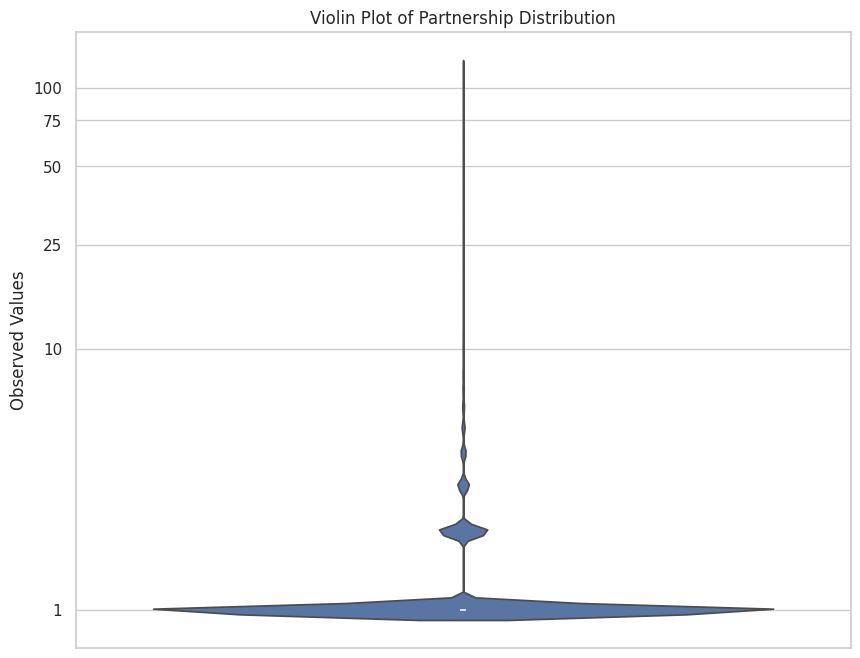

In [24]:
plt.figure(figsize=(10, 8))
plt.title("Violin Plot of Partnership Distribution")

sns.violinplot(ranking_by_partnerships, log_scale=True)

plt.yticks([1, 10, 25, 50, 75, 100])

plt.gca().get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

plt.ylabel("Observed Values")

plt.show()

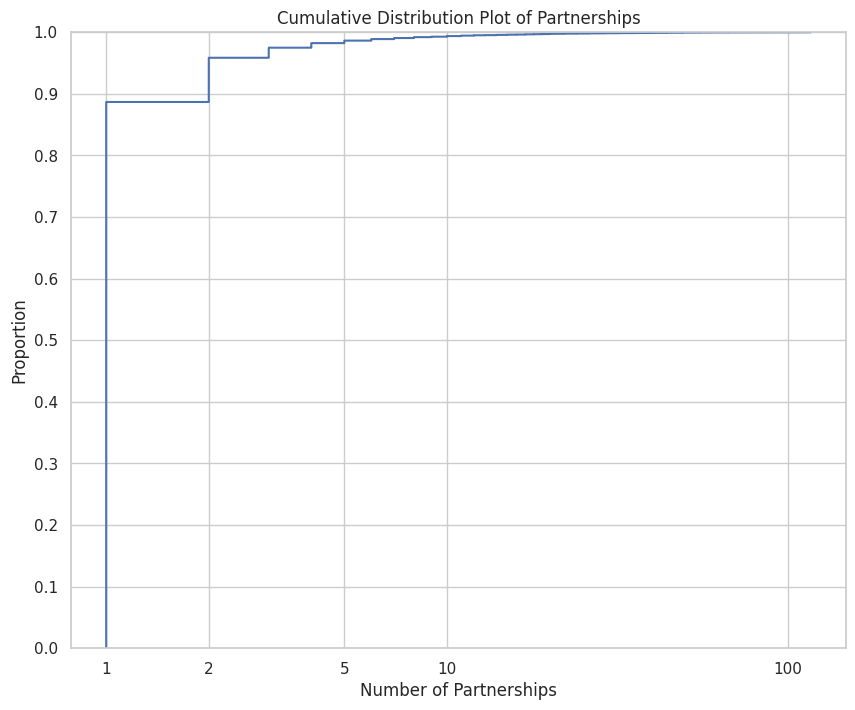

In [25]:
plt.figure(figsize=(10, 8))
plt.title("Cumulative Distribution Plot of Partnerships")

sns.ecdfplot(ranking_by_partnerships, log_scale=10)

plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks([1, 2, 5, 10, 100])

plt.gca().get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

plt.xlabel("Number of Partnerships")

plt.show()

Perhaps, the disbalance in distribution towards just one is due to the fact that many **independent developers** own the same publishing company.

In [26]:
indie_pub_names = ranking_by_partnerships[ranking_by_partnerships == 1].index

indie_devs = df_pub_dev[
    df_pub_dev['developer_name'].isin(indie_pub_names)
][
    ['publisher_name', 'developer_name']
]

indie_devs.head()

,publisher_name,developer_name
8,Dovetail Games - Trains,Dovetail Games
9,Dovetail Games,Dovetail Games
11,Wolfire Games,Wolfire Games
13,FireFly Studios,FireFly Studios
14,Devolver Digital,Croteam


In [27]:
print(f"Total proportion of coincidences in names: {
    round(
        100 * (indie_devs['publisher_name'] == indie_devs['developer_name']).sum() / len(indie_devs),
        1
    )
}%")

Total proportion of coincidences in names: 92.7%


In [28]:
publisher_stats = pd.merge(
    df_pub_dev.groupby('publisher_id')['appid'].nunique(),
    df_pub_dev.groupby('publisher_id')['developer_id'].nunique(),
    on='publisher_id'
).rename(columns={'appid': 'volume', 'developer_id': 'partnerships'})

publisher_stats.head()

,volume,partnerships
publisher_id,,
2,4,4
3,1,1
4,1,1
5,1,1
6,1,2


In [29]:
filtered_ranks = publisher_stats[publisher_stats['partnerships'] > 10].sort_values(by='volume', ascending=False)

In [30]:
print(f"The number of publishers with more than 10 partnerships is {len(filtered_ranks)}")

The number of publishers with more than 10 partnerships is 369


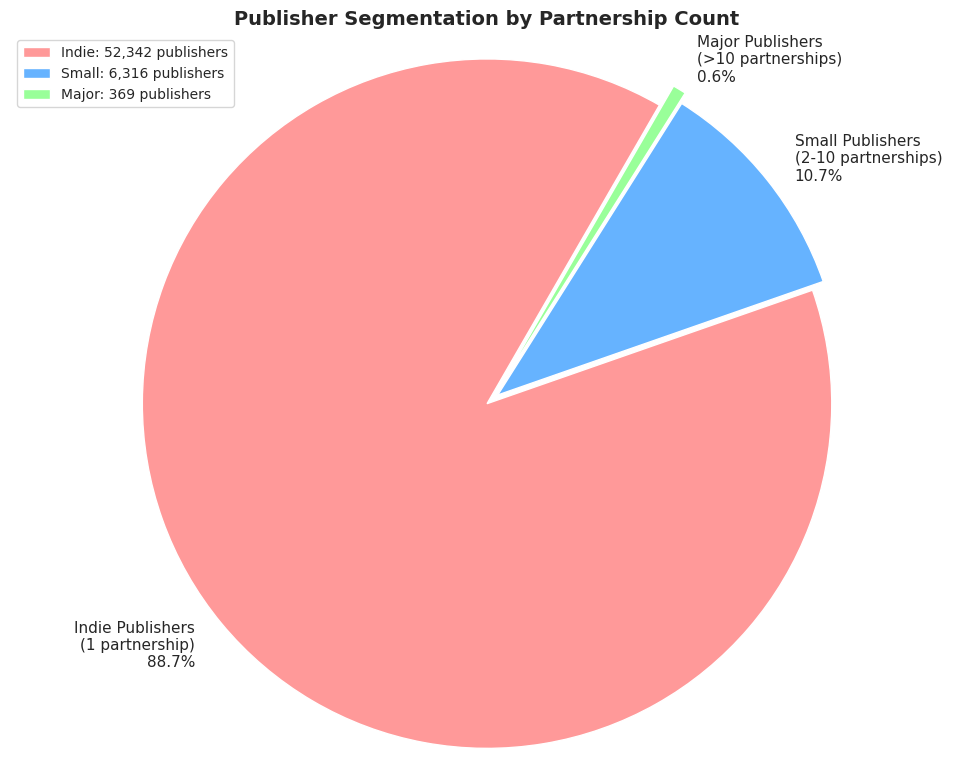

Total publishers: 59,027
Indie publishers (1 partnership): 52,342 (88.7%)
Small publishers (2-10 partnerships): 6,316 (10.7%)
Major publishers (>10 partnerships): 369 (0.6%)

Major publishers with >10 partnerships: 369


In [31]:
# Calculate counts for each category
indie_publishers = len(publisher_stats[publisher_stats['partnerships'] == 1])
small_publishers = len(publisher_stats[(publisher_stats['partnerships'] > 1) & 
                                       (publisher_stats['partnerships'] <= 10)])
major_publishers = len(publisher_stats[publisher_stats['partnerships'] > 10])

# Create pie chart
plt.figure(figsize=(10, 8))
categories = ['Indie Publishers\n(1 partnership)', 
              'Small Publishers\n(2-10 partnerships)', 
              'Major Publishers\n(>10 partnerships)']
counts = [indie_publishers, small_publishers, major_publishers]
colors = ['#ff9999', '#66b3ff', '#99ff99']

# Calculate percentages for labels
total_publishers = sum(counts)
percentages = [f'{count/total_publishers*100:.1f}%' for count in counts]
labels = [f'{cat}\n{perc}' for cat, perc in zip(categories, percentages)]

plt.pie(counts, 
        labels=labels,
        colors=colors,
        autopct='',
        startangle=60,
        explode=(0.02, 0.02, 0.05),
        textprops={'fontsize': 11})
plt.title('Publisher Segmentation by Partnership Count', fontsize=14, fontweight='bold')
plt.axis('equal')

# Add legend with actual counts
legend_labels = [f'{cat}: {count:,} publishers' for cat, count in zip(
    ['Indie', 'Small', 'Major'], counts)]
plt.legend(legend_labels, loc='best', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Total publishers: {total_publishers:,}")
print(f"Indie publishers (1 partnership): {indie_publishers:,} ({indie_publishers/total_publishers*100:.1f}%)")
print(f"Small publishers (2-10 partnerships): {small_publishers:,} ({small_publishers/total_publishers*100:.1f}%)")
print(f"Major publishers (>10 partnerships): {major_publishers:,} ({major_publishers/total_publishers*100:.1f}%)")
print(f"\nMajor publishers with >10 partnerships: {len(filtered_ranks)}")

In [32]:
filtered_ranks.head(10)

,volume,partnerships
publisher_id,,
58543,529,58
2444,268,14
29366,193,98
47163,183,114
39735,181,59
66888,172,97
13845,171,14
20019,160,87
9650,144,117


In [33]:
df_pub_dev_filtered = \
    df_pub_dev[df_pub_dev['publisher_id'].isin(filtered_ranks.index)]

In [34]:
filtered_grouped_by_publisher = df_pub_dev_filtered.groupby('publisher_name')

filtered_ranking_by_volume = filtered_grouped_by_publisher['appid'].nunique().sort_values(ascending=False)

filtered_ranking_by_volume.head(10)

publisher_name
Big Fish Games     529
8floor             268
PlayWay S.A.       193
Kagura Games       183
HH-Games           181
Conglomerate 5     172
Laush Studio       171
Sekai Project      160
Plug In Digital    144
My Way Games       142
Name: appid, dtype: int64

In [35]:
filtered_total_volume = filtered_ranking_by_volume.sum()

filtered_percent_volume = (filtered_ranking_by_volume / filtered_total_volume)

filtered_percent_volume.head(10)

publisher_name
Big Fish Games    0.04
8floor            0.02
PlayWay S.A.      0.01
Kagura Games      0.01
HH-Games          0.01
Conglomerate 5    0.01
Laush Studio      0.01
Sekai Project     0.01
Plug In Digital   0.01
My Way Games      0.01
Name: appid, dtype: float64

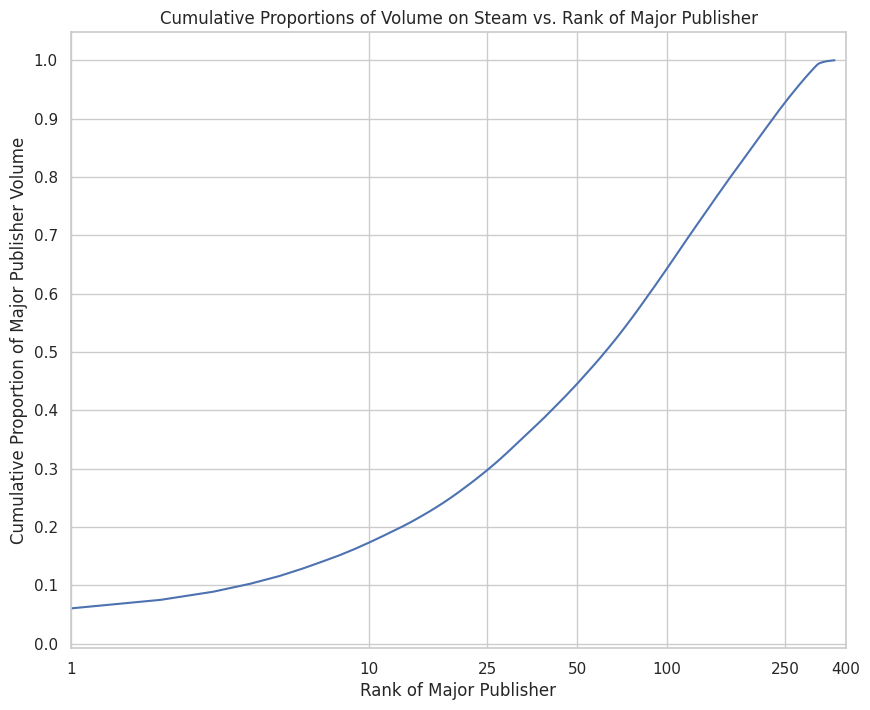

In [36]:
plt.figure(figsize=(10, 8))
plt.title("Cumulative Proportions of Volume on Steam vs. Rank of Major Publisher")

plt.xlabel("Rank of Major Publisher")
plt.ylabel("Cumulative Proportion of Major Publisher Volume")

plt.xscale('log')

plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks([1, 10, 25, 50, 100, 250, 400])
plt.xlim([1, 400])

plt.gca().get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

plt.plot(range(len(filtered_percent_volume)), np.cumsum(filtered_percent_volume))

#### Examine the cumulative developers proportion w.r.t. rank of publisher:

In [37]:
filtered_ranking_by_partnerships = filtered_grouped_by_publisher['developer_id'].nunique().sort_values(ascending=False)
filtered_ranking_by_partnerships.head(10)

publisher_name
Plug In Digital                    117
Kagura Games                       114
DigiPen Institute of Technology    111
indie.io                           107
PlayWay S.A.                        98
Conglomerate 5                      97
Devolver Digital                    94
PLAYISM                             93
Gamirror Games                      89
Sekai Project                       87
Name: developer_id, dtype: int64

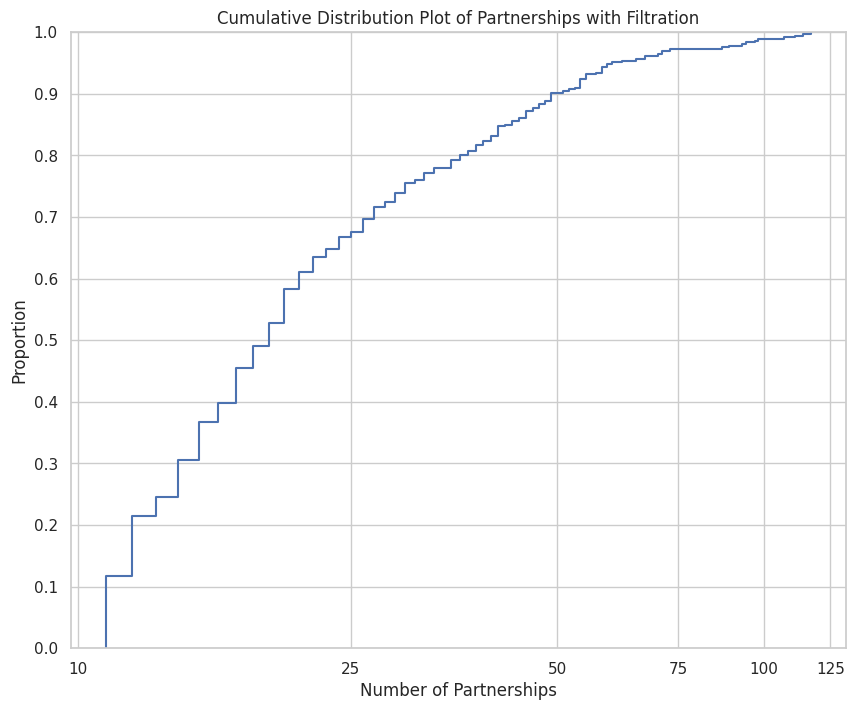

In [38]:
plt.figure(figsize=(10, 8))
plt.title("Cumulative Distribution Plot of Partnerships with Filtration")

sns.ecdfplot(filtered_ranking_by_partnerships, log_scale=10)

plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks([10, 25, 50, 75, 100, 125])

plt.gca().get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

plt.xlabel("Number of Partnerships")

plt.show()

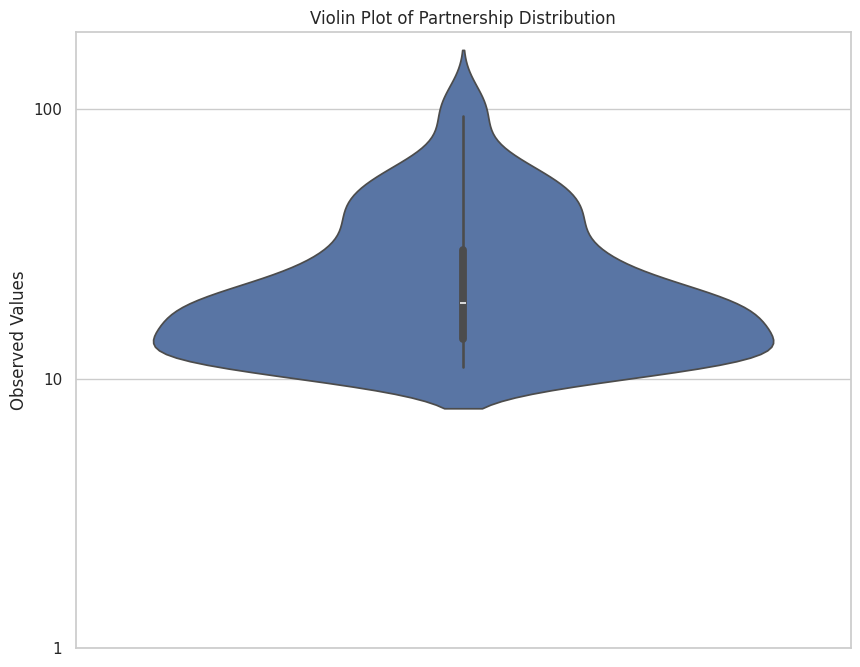

In [39]:
plt.figure(figsize=(10, 8))
plt.title("Violin Plot of Partnership Distribution")

sns.violinplot(filtered_ranking_by_partnerships, log_scale=True)

plt.yticks([1, 10, 100])

plt.gca().get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

plt.ylabel("Observed Values")

plt.show()

#### Given Major publishers definition, evaluate the cumulative coverage of developers such publishers worked with among all developers

In [40]:
total_partnerships = ranking_by_partnerships.sum()

filtered_percent_partnerships = (filtered_ranking_by_partnerships / total_partnerships)

filtered_percent_partnerships.head(10)

publisher_name
Plug In Digital                   0.00
Kagura Games                      0.00
DigiPen Institute of Technology   0.00
indie.io                          0.00
PlayWay S.A.                      0.00
Conglomerate 5                    0.00
Devolver Digital                  0.00
PLAYISM                           0.00
Gamirror Games                    0.00
Sekai Project                     0.00
Name: developer_id, dtype: float64

In [41]:
total_partnerships

np.int64(79324)

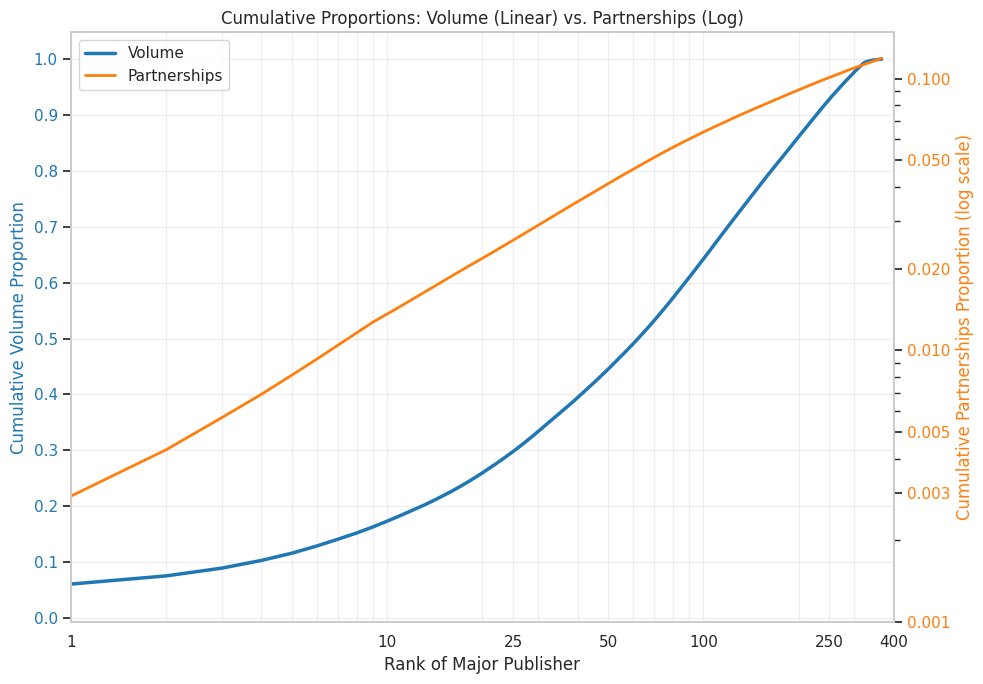

In [42]:
fig, ax1 = plt.subplots(figsize=(10, 7))

color = 'tab:blue'
ax1.set_xlabel('Rank of Major Publisher')
ax1.set_ylabel('Cumulative Volume Proportion', color=color)
ax1.plot(range(len(filtered_percent_volume)), np.cumsum(filtered_percent_volume), 
         color=color, label='Volume', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.set_xticks([1, 10, 25, 50, 100, 250, 400])
ax1.set_yticks(np.arange(0, 1.1, 0.1))
ax1.set_xlim([1, 400])
ax1.grid(True, alpha=0.3, which='both')
ax1.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Cumulative Partnerships Proportion (log scale)', color=color)
ax2.set_yscale('log')
ax2.plot(range(len(filtered_percent_partnerships)), np.cumsum(filtered_percent_partnerships), 
         color=color, label='Partnerships', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yticks([0.001, 0.003, 0.005, 0.01, 0.02, 0.05, 0.1])
ax2.grid(False)
ax2.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Cumulative Proportions: Volume (Linear) vs. Partnerships (Log)')
plt.tight_layout()
plt.show()

Select top $p$ publishers such that the volume coverage is at least $50\%$ and the resulting top consist of no more than $30\%$ of all major developers:

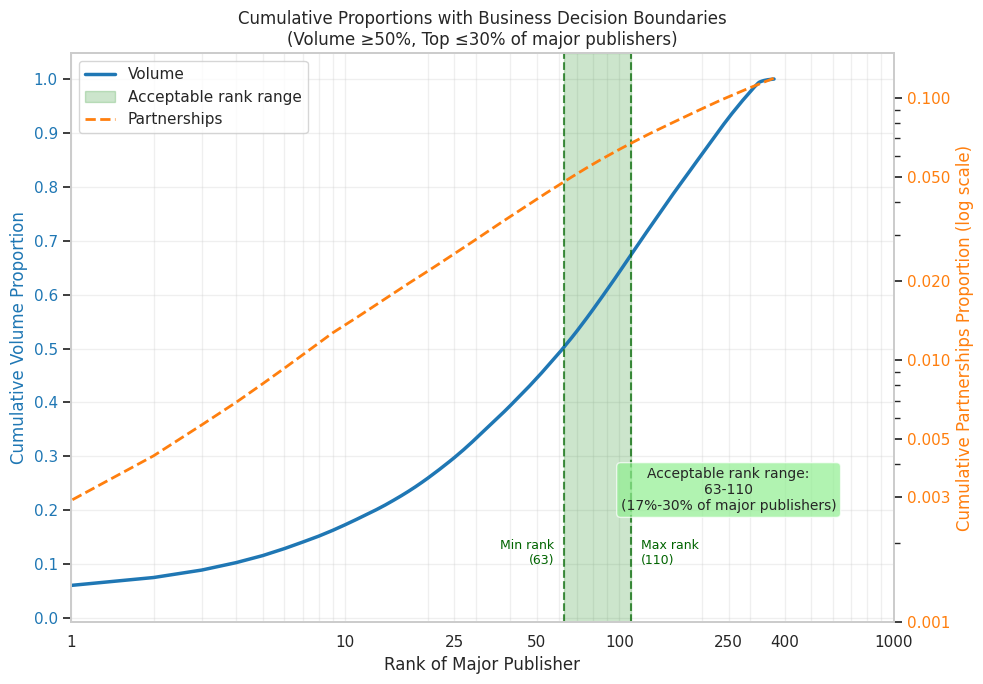

In [43]:
fig, ax1 = plt.subplots(figsize=(10, 7))

color = 'tab:blue'
ax1.set_xlabel('Rank of Major Publisher')
ax1.set_ylabel('Cumulative Volume Proportion', color=color)
volume_cumsum = np.cumsum(filtered_percent_volume)
ax1.plot(range(len(filtered_percent_volume)), volume_cumsum, 
         color=color, label='Volume', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.set_xticks([1, 10, 25, 50, 100, 250, 400, 1000])
ax1.set_yticks(np.arange(0, 1.1, 0.1))
ax1.set_xlim([1, 1000])
ax1.grid(True, alpha=0.3, which='both')
ax1.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Cumulative Partnerships Proportion (log scale)', color=color)
ax2.set_yscale('log')
partnerships_cumsum = np.cumsum(filtered_percent_partnerships)
ax2.plot(range(len(filtered_percent_partnerships)), partnerships_cumsum, 
         color=color, label='Partnerships', linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yticks([0.001, 0.003, 0.005, 0.01, 0.02, 0.05, 0.1])
ax2.grid(False)
ax2.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())

# Add business decision boundaries
# Top p publishers should cover at least 50% volume
volume_threshold = 0.5
volume_rank_threshold = np.argmax(volume_cumsum >= volume_threshold)

# But at least 30% of major publishers should NOT be considered as top
# => top boundary is 70% of major publishers
max_rank = len(filtered_percent_volume)
lower_bound = volume_rank_threshold
upper_bound = int(max_rank * 0.3)

# Highlight the acceptable region
ax1.axvspan(lower_bound, upper_bound, alpha=0.2, color='green', label='Acceptable rank range')

# Add vertical lines at boundaries
ax1.axvline(x=lower_bound, color='darkgreen', linestyle='--', alpha=0.7, linewidth=1.5)
ax1.axvline(x=upper_bound, color='darkgreen', linestyle='--', alpha=0.7, linewidth=1.5)

# Add annotations
ax1.text(lower_bound-5, 0.1, f'Min rank\n({lower_bound})', 
         ha='right', fontsize=9, color='darkgreen')
ax1.text(upper_bound+10, 0.1, f'Max rank\n({upper_bound})', 
         ha='left', fontsize=9, color='darkgreen')

# # Add text explaining the boundaries
ax1.text(250, 0.2, f'Acceptable rank range:\n{lower_bound}-{upper_bound}\n'
         f'({lower_bound/max_rank*100:.0f}%-{upper_bound/max_rank*100:.0f}% of major publishers)',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7),
         fontsize=10, ha='center')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Cumulative Proportions with Business Decision Boundaries\n'
          f'(Volume ≥50%, Top ≤30% of major publishers)')
plt.tight_layout()
plt.show()

Select $p=100$

In [44]:
p = 100

top_p_pubs = filtered_ranks.head(p)

print(f"Top {p} publishers cover {
    round(100 * np.sum(filtered_percent_volume.head(p)), 2)
}% of volume (excluding independent and small publishers) and have partenerships with {
    round(100 * np.sum(filtered_percent_partnerships.head(p)), 2)
}% of all developers")

Top 100 publishers cover 63.91% of volume (excluding independent and small publishers) and have partenerships with 6.32% of all developers


In [45]:
top_developers = df_pub_dev[df_pub_dev['publisher_id'].isin(top_p_pubs.index)]

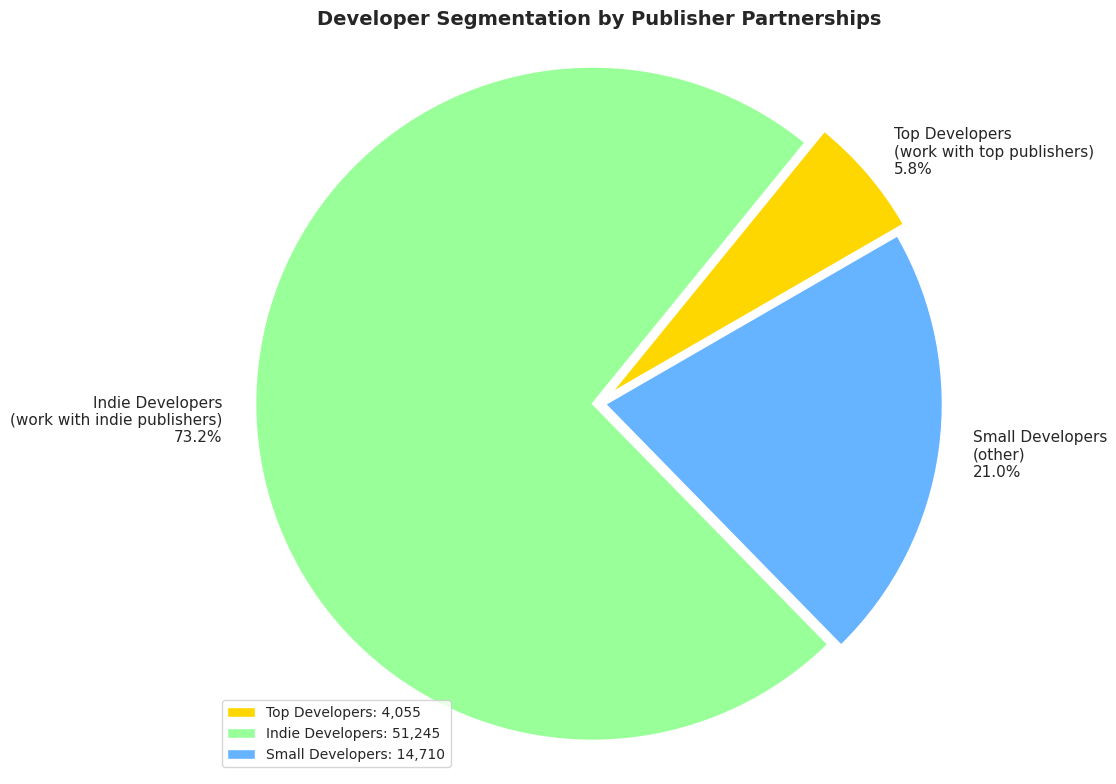

Total developers: 70,010
Top developers (work with top publishers): 4,055 (5.8%)
Indie developers (work with indie publishers): 51,245 (73.2%)
Small developers (other): 14,710 (21.0%)

Verification - Sum of segments: 70,010
Should equal total developers: 70,010


In [46]:
# Pie chart of developer segmentation by publisher partnerships

# Calculate counts for each category
# Top developers (work with top p publishers by volume)
top_p_pubs = filtered_ranks.head(p)
top_developers = df_pub_dev[df_pub_dev['publisher_id'].isin(top_p_pubs.index)]
top_dev_count = top_developers['developer_id'].nunique()

# Indie developers (work with publishers that have exactly 1 partnership)
indie_pub_names = ranking_by_partnerships[ranking_by_partnerships == 1].index
indie_devs = df_pub_dev[df_pub_dev['publisher_name'].isin(indie_pub_names)]
indie_dev_count = indie_devs['developer_id'].nunique()

# Small developers (all remaining developers)
total_developers = df_pub_dev['developer_id'].nunique()
small_dev_count = total_developers - top_dev_count - indie_dev_count

# Create pie chart
plt.figure(figsize=(10, 8))
categories = ['Top Developers\n(work with top publishers)', 
              'Indie Developers\n(work with indie publishers)', 
              'Small Developers\n(other)']
counts = [top_dev_count, indie_dev_count, small_dev_count]
colors = ['#ffd700', '#99ff99', '#66b3ff']  # Gold for top, light green for indie, blue for small

# Calculate percentages
total = sum(counts)
percentages = [f'{count/total*100:.1f}%' for count in counts]
labels = [f'{cat}\n{perc}' for cat, perc in zip(categories, percentages)]

# Explode the top developers slice slightly to highlight
explode = (0.05, 0.02, 0.02)

plt.pie(counts, 
        labels=labels,
        colors=colors,
        autopct='',  # Empty since we added percentages manually
        startangle=30,
        explode=explode,
        textprops={'fontsize': 11})
plt.title('Developer Segmentation by Publisher Partnerships', fontsize=14, fontweight='bold')
plt.axis('equal')

# Add legend with actual counts
legend_labels = [
    f'Top Developers: {top_dev_count:,}',
    f'Indie Developers: {indie_dev_count:,}',
    f'Small Developers: {small_dev_count:,}'
]
plt.legend(legend_labels, loc='best', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary
print(f"Total developers: {total:,}")
print(f"Top developers (work with top publishers): {top_dev_count:,} ({top_dev_count/total*100:.1f}%)")
print(f"Indie developers (work with indie publishers): {indie_dev_count:,} ({indie_dev_count/total*100:.1f}%)")
print(f"Small developers (other): {small_dev_count:,} ({small_dev_count/total*100:.1f}%)")

# Verify the math
print(f"\nVerification - Sum of segments: {top_dev_count + indie_dev_count + small_dev_count:,}")
print(f"Should equal total developers: {total:,}")

### Exploring Reviews for Possible Features

In [47]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048148 entries, 0 to 1048147
Data columns (total 23 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   recommendationid                1048148 non-null  int64  
 1   appid                           1048148 non-null  int64  
 2   author_steamid                  1048148 non-null  int64  
 3   author_num_games_owned          1048148 non-null  int64  
 4   author_num_reviews              1048148 non-null  int64  
 5   author_playtime_forever         1048145 non-null  float64
 6   author_playtime_last_two_weeks  1048145 non-null  float64
 7   author_playtime_at_review       869291 non-null   float64
 8   author_last_played              1048145 non-null  float64
 9   language                        1048148 non-null  object 
 10  review_text                     1047369 non-null  object 
 11  timestamp_created               1048148 non-null  int64  
 12  

#### Find top developers and their games

In [48]:
df_game_dev_rev = df_game_dev.merge(
    df_reviews,
    on='appid',
    how='left'
)

In [49]:
df_game_dev_rev[
    df_game_dev_rev['developer_id'].isin(
            top_developers['developer_id']
    )
].nunique()['developer_id']

np.int64(4055)

In [50]:
df_games_with_devs = df_games.merge(
    df_game_dev.merge(
        df_dev,
        left_on='developer_id',
        right_on='id'
    ).drop(columns=['id']).rename(columns={'name': 'developer_name'}),
    on='appid'
)

In [51]:
top_dev_games = df_games_with_devs[
    df_games_with_devs['developer_id'].isin(top_developers['developer_id'])
]

#### Count games without reviews

Steam Reviews API samples only up to 10 reviews per game. No sampled reviews does not mean game has zero reviews on Steam:

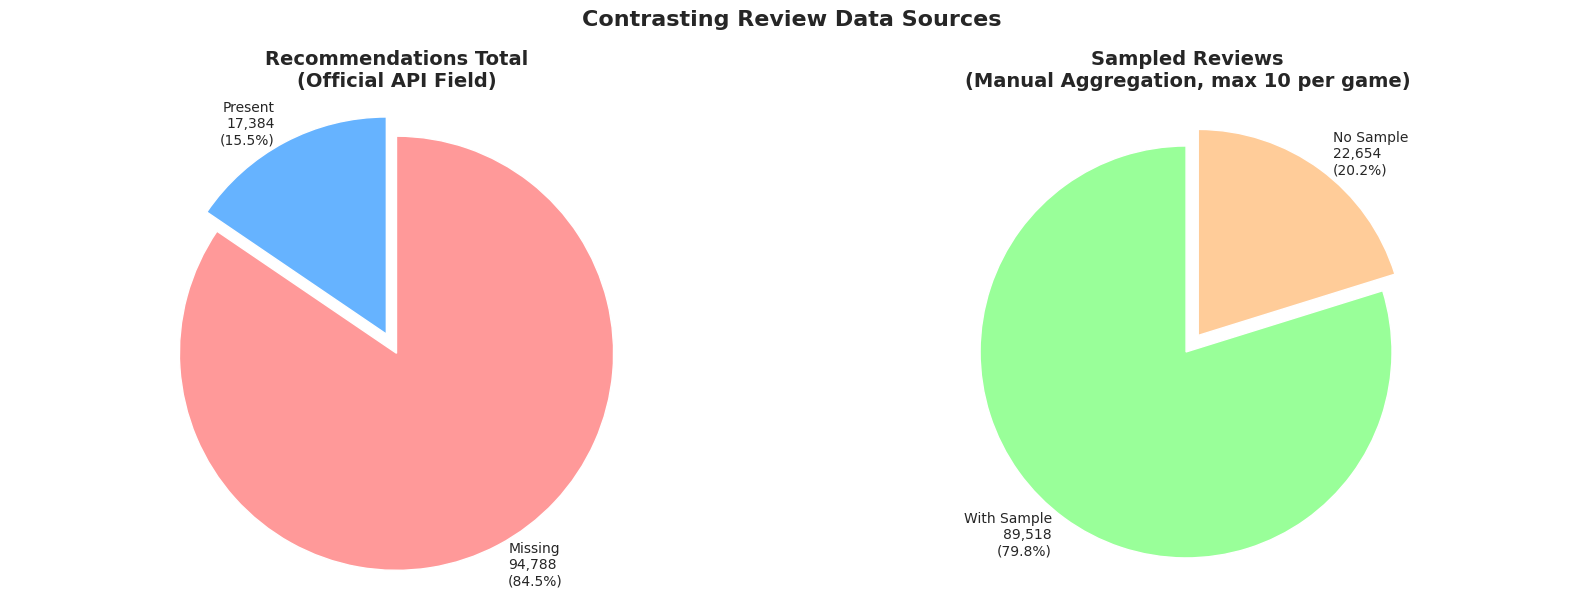

DETAILED COMPARISON: Recommendations Total vs. Sampled Reviews
Metric                                          Count   Percentage
----------------------------------------------------------------
Total games                                   112,172       100.0%
Games with recommendations_total               17,384        15.5%
Games with sampled reviews                     89,518        79.8%
Games missing recommendations_total            94,788        84.5%
Games without sampled reviews                  22,654        20.2%
Games with BOTH sources                        17,298        15.4%


In [52]:
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- Plot 1: Recommendations Total Coverage (left) ---
missing_rec_total = df_games['recommendations_total'].isna().sum()
present_rec_total = len(df_games) - missing_rec_total
total_games = len(df_games)

# Data for left pie
categories_left = ['Present', 'Missing']
counts_left = [present_rec_total, missing_rec_total]
colors_left = ['#66b3ff', '#ff9999']
explode_left = (0, 0.1)

# Calculate percentages
present_percent = present_rec_total/total_games*100
missing_percent = missing_rec_total/total_games*100

# Create labels with counts and percentages
labels_left = [
    f'Present\n{present_rec_total:,}\n({present_percent:.1f}%)',
    f'Missing\n{missing_rec_total:,}\n({missing_percent:.1f}%)'
]

# Plot left pie
wedges1, texts1, autotexts1 = ax1.pie(counts_left, 
                                       labels=labels_left,
                                       colors=colors_left,
                                       autopct='',  # Manual labels
                                       startangle=90,
                                       explode=explode_left,
                                       textprops={'fontsize': 10},
                                       wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax1.set_title('Recommendations Total\n(Official API Field)', fontsize=14, fontweight='bold')
ax1.axis('equal')

# --- Plot 2: Sampled Reviews Coverage (right) ---
review_count_per_game = df_game_dev_rev.groupby('appid')['recommendationid'].nunique()
games_with_no_review = review_count_per_game[review_count_per_game == 0].count()
games_with_review = len(df_games) - games_with_no_review

# Data for right pie
categories_right = ['With Sample', 'No Sample']
counts_right = [games_with_review, games_with_no_review]
colors_right = ['#99ff99', '#ffcc99']  # Different color scheme
explode_right = (0, 0.1)

# Calculate percentages
sample_present_percent = games_with_review/total_games*100
sample_missing_percent = games_with_no_review/total_games*100

# Create labels with counts and percentages
labels_right = [
    f'With Sample\n{games_with_review:,}\n({sample_present_percent:.1f}%)',
    f'No Sample\n{games_with_no_review:,}\n({sample_missing_percent:.1f}%)'
]

# Plot right pie
wedges2, texts2, autotexts2 = ax2.pie(counts_right,
                                       labels=labels_right,
                                       colors=colors_right,
                                       autopct='',  # Manual labels
                                       startangle=90,
                                       explode=explode_right,
                                       textprops={'fontsize': 10},
                                       wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax2.set_title('Sampled Reviews\n(Manual Aggregation, max 10 per game)', fontsize=14, fontweight='bold')
ax2.axis('equal')

plt.suptitle('Contrasting Review Data Sources', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Make room for explanation text
plt.show()

# Print detailed comparison
print("=" * 60)
print("DETAILED COMPARISON: Recommendations Total vs. Sampled Reviews")
print("=" * 60)
print(f"{'Metric':<40} {'Count':>12} {'Percentage':>12}")
print("-" * 64)
print(f"{'Total games':<40} {total_games:>12,} {100.0:>11.1f}%")
print(f"{'Games with recommendations_total':<40} {present_rec_total:>12,} {present_percent:>11.1f}%")
print(f"{'Games with sampled reviews':<40} {games_with_review:>12,} {sample_present_percent:>11.1f}%")
print(f"{'Games missing recommendations_total':<40} {missing_rec_total:>12,} {missing_percent:>11.1f}%")
print(f"{'Games without sampled reviews':<40} {games_with_no_review:>12,} {sample_missing_percent:>11.1f}%")

# Calculate overlap if possible
games_with_both = df_games[
    (~df_games['recommendations_total'].isna()) & 
    (df_games['appid'].isin(review_count_per_game[review_count_per_game > 0].index))
].shape[0]
print(f"{'Games with BOTH sources':<40} {games_with_both:>12,} {games_with_both/total_games*100:>11.1f}%")
print("=" * 60)

Manual aggregation results in larger number of games with reviews making this feature more reliable compared to `recommendations_total`.

In [53]:
games_with_reviews = review_count_per_game[review_count_per_game > 0].index
games_with_reviews

Index([   1313,    7800,    8980,   11550,   12210,   12364,   24010,   24880,
         25000,   38400,
       ...
       3947360, 3947700, 3948620, 3948850, 3950300, 3951970, 3953720, 3954630,
       3957590, 3959570],
      dtype='int64', name='appid', length=81935)

#### Count developers without reviews

In [54]:
# 1. What proportion of ALL developers appear in df_game_dev_rev
devs_in_sample = df_game_dev_rev['developer_id'].nunique()
total_devs = df_dev['id'].nunique()
print(f"Developers in sample: {devs_in_sample}/{total_devs} = {100*devs_in_sample/total_devs:.1f}%")

# 2. Among developers in sample, what proportion have reviews
devs_in_sample_with_reviews = df_game_dev_rev[
    df_game_dev_rev['appid'].isin(games_with_reviews)
]['developer_id'].nunique()
print(f"Developers in sample WITH reviews: {devs_in_sample_with_reviews}/{devs_in_sample} = {100*devs_in_sample_with_reviews/devs_in_sample:.1f}%")

# 3. Overall proportion
overall = 100 * devs_in_sample_with_reviews / total_devs
print(f"OVERALL: {overall:.1f}% of all developers have reviews")

Developers in sample: 70219/101226 = 69.4%
Developers in sample WITH reviews: 53280/70219 = 75.9%
OVERALL: 52.6% of all developers have reviews


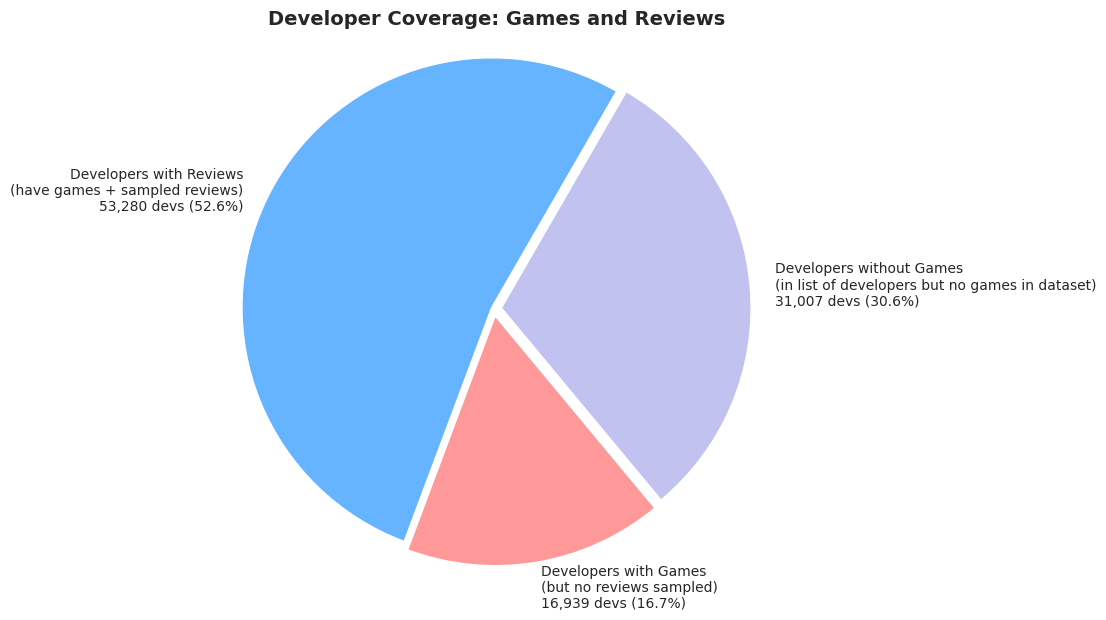

DEVELOPER COVERAGE SUMMARY
Category                                   Count   Percentage
-------------------------------------------------------------
Total developers                         101,226       100.0%
With reviews                              53,280        52.6%
With games (no reviews)                   16,939        16.7%
Without games                             31,007        30.6%


In [55]:
# Calculate the three categories
total_devs = df_dev['id'].nunique()
devs_with_games = df_game_dev['developer_id'].nunique()

# Among developers with games, which have sampled reviews?
games_with_reviews = df_game_dev_rev.groupby('appid')['recommendationid'].nunique()
games_with_reviews = games_with_reviews[games_with_reviews > 0].index

devs_with_reviews = df_game_dev_rev[
    df_game_dev_rev['appid'].isin(games_with_reviews)
]['developer_id'].nunique()

devs_with_games_no_reviews = devs_with_games - devs_with_reviews
devs_without_games = total_devs - devs_with_games

# Create pie chart
plt.figure(figsize=(10, 8))

categories = [
    'Developers with Reviews\n(have games + sampled reviews)',
    'Developers with Games\n(but no reviews sampled)',
    'Developers without Games\n(in list of developers but no games in dataset)'
]
counts = [devs_with_reviews, devs_with_games_no_reviews, devs_without_games]
colors = ['#66b3ff', '#ff9999', '#c2c2f0']  # Blue, red, purple

# Calculate percentages
percentages = [f'{count/total_devs*100:.1f}%' for count in counts]
labels = [f'{cat}\n{count:,} devs ({perc})' for cat, count, perc in zip(categories, counts, percentages)]

# Explode the "with reviews" slice
explode = (0.01, 0.03, 0.03)

plt.pie(counts, 
        labels=labels,
        colors=colors,
        autopct='',  # Manual labels
        startangle=60,
        explode=explode,
        textprops={'fontsize': 10},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Developer Coverage: Games and Reviews', fontsize=14, fontweight='bold')
plt.axis('equal')


plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

# Print summary
print("=" * 60)
print("DEVELOPER COVERAGE SUMMARY")
print("=" * 60)
print(f"{'Category':<35} {'Count':>12} {'Percentage':>12}")
print("-" * 61)
print(f"{'Total developers':<35} {total_devs:>12,} {100.0:>11.1f}%")
print(f"{'With reviews':<35} {devs_with_reviews:>12,} {devs_with_reviews/total_devs*100:>11.1f}%")
print(f"{'With games (no reviews)':<35} {devs_with_games_no_reviews:>12,} {devs_with_games_no_reviews/total_devs*100:>11.1f}%")
print(f"{'Without games':<35} {devs_without_games:>12,} {devs_without_games/total_devs*100:>11.1f}%")
print("=" * 60)

In [56]:
# Developers who have at least one game with reviews
# (appears in df_game_dev_rev AND that game is in games_with_reviews)
devs_with_reviews = df_game_dev_rev[
    df_game_dev_rev['appid'].isin(games_with_reviews)
]['developer_id'].unique()

devs_with_reviews_set = set(devs_with_reviews)

In [57]:
top_devs_count = len(top_developers)
all_devs_count = len(df_dev['id'])

In [58]:
# Top developers with reviews
top_devs_with_reviews = [dev for dev in top_developers.index if dev in devs_with_reviews_set]
top_coverage = len(top_devs_with_reviews) / top_devs_count

# All developers with reviews
all_devs_with_reviews = [dev for dev in df_dev['id'] if dev in devs_with_reviews_set]
all_coverage = len(all_devs_with_reviews) / all_devs_count

print(f"Top developers with reviews: {len(top_devs_with_reviews)}/{top_devs_count} = {top_coverage:.1%}")
print(f"All developers with reviews: {len(all_devs_with_reviews)}/{all_devs_count} = {all_coverage:.1%}")
print(f"Coverage ratio (top/all): {top_coverage/all_coverage:.2f}x")

Top developers with reviews: 4817/9682 = 49.8%
All developers with reviews: 53280/101226 = 52.6%
Coverage ratio (top/all): 0.95x


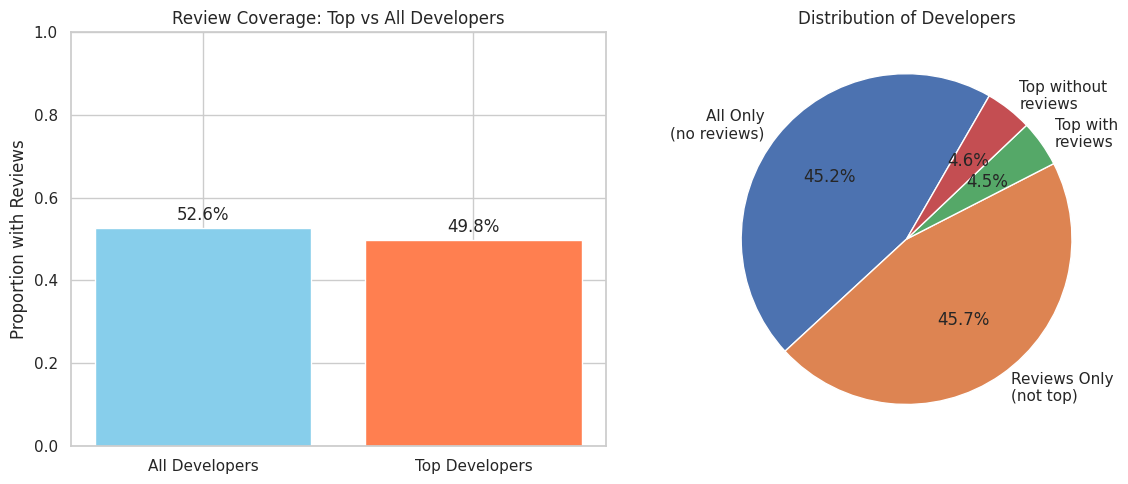

In [59]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart comparison
categories = ['All Developers', 'Top Developers']
coverage = [all_coverage, top_coverage]
bars = ax1.bar(categories, coverage, color=['skyblue', 'coral'])
ax1.set_ylabel('Proportion with Reviews')
ax1.set_title('Review Coverage: Top vs All Developers')
ax1.set_ylim(0, 1)

# Add percentage labels
for bar, val in zip(bars, coverage):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.1%}', ha='center')

# Venn diagram style representation
sizes = [
    len(set(df_dev['id']) - devs_with_reviews_set),  # All only (no reviews)
    len(devs_with_reviews_set - set(top_developers.index)),  # Reviews only (not top)
    len(set(top_developers.index) & devs_with_reviews_set),  # Top with reviews
    len(set(top_developers.index) - devs_with_reviews_set)   # Top without reviews
]

ax2.pie(sizes, labels=['All Only\n(no reviews)', 'Reviews Only\n(not top)', 
                       'Top with\nreviews', 'Top without\nreviews'],
        autopct='%1.1f%%', startangle=60)
ax2.set_title('Distribution of Developers')

plt.tight_layout()
plt.show()

#### Macro Aggregation of Metrics

In [60]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (mean1 - mean2) / pooled_std

In [61]:
statistical_columns = df_game_dev_rev.drop(
    columns=['appid', 'developer_id', 'recommendationid', 'author_steamid', 'timestamp_created', 'timestamp_updated']
).select_dtypes(include=['number', 'bool']).columns

In [62]:
statistical_columns

Index(['author_num_games_owned', 'author_num_reviews',
       'author_playtime_forever', 'author_playtime_last_two_weeks',
       'author_playtime_at_review', 'author_last_played', 'votes_up',
       'votes_funny', 'weighted_vote_score', 'comment_count'],
      dtype='object')

In [63]:
# Step 1: Calculate per-game metrics
per_game_metrics = df_game_dev_rev[
    df_game_dev_rev['appid'].isin(games_with_reviews)
].groupby(['developer_id', 'appid'])[statistical_columns].mean()

# Step 2: Aggregate to developer level (mean of per-game metrics)
developer_metrics = per_game_metrics.groupby('developer_id').mean()

In [64]:
top_ids = set(top_developers['developer_id'])
developer_metrics['is_top'] = developer_metrics.index.isin(top_ids).astype(int)

In [65]:
statistics = dict.fromkeys(statistical_columns)

for column in statistical_columns:
    group1 = developer_metrics[developer_metrics['is_top']==1][column]
    group2 = developer_metrics[developer_metrics['is_top']==0][column]

    statistics[column] = cohens_d(group1, group2)

In [66]:
print("Cohen's d (positive means top developers have higher values):")
print(pd.Series(statistics).sort_values(ascending=False))

Cohen's d (positive means top developers have higher values):
author_last_played                0.43
author_playtime_last_two_weeks    0.28
author_num_reviews                0.13
author_playtime_at_review         0.10
author_num_games_owned            0.09
author_playtime_forever           0.05
votes_funny                      -0.01
comment_count                    -0.05
votes_up                         -0.09
weighted_vote_score              -0.12
dtype: float64


In [67]:
per_game_selected_metrics = df_game_dev_rev[
    df_game_dev_rev['appid'].isin(games_with_reviews)
].groupby(['developer_id', 'appid'])[[
    'author_last_played',
    'author_playtime_last_two_weeks',
    'author_num_reviews',
    'author_num_games_owned',
    'author_playtime_forever',
    'weighted_vote_score',
    'voted_up'
]].mean()

developer_selected_metrics = per_game_selected_metrics.groupby('developer_id').mean()

developer_selected_metrics['voted_up'] = developer_selected_metrics['voted_up'].astype(np.float64)

In [68]:
selected_columns = developer_selected_metrics.columns

In [69]:
# Add target variable (is_top)
top_ids = set(top_developers['developer_id'])
developer_selected_metrics['is_top'] = developer_selected_metrics.index.isin(top_ids).astype(int)

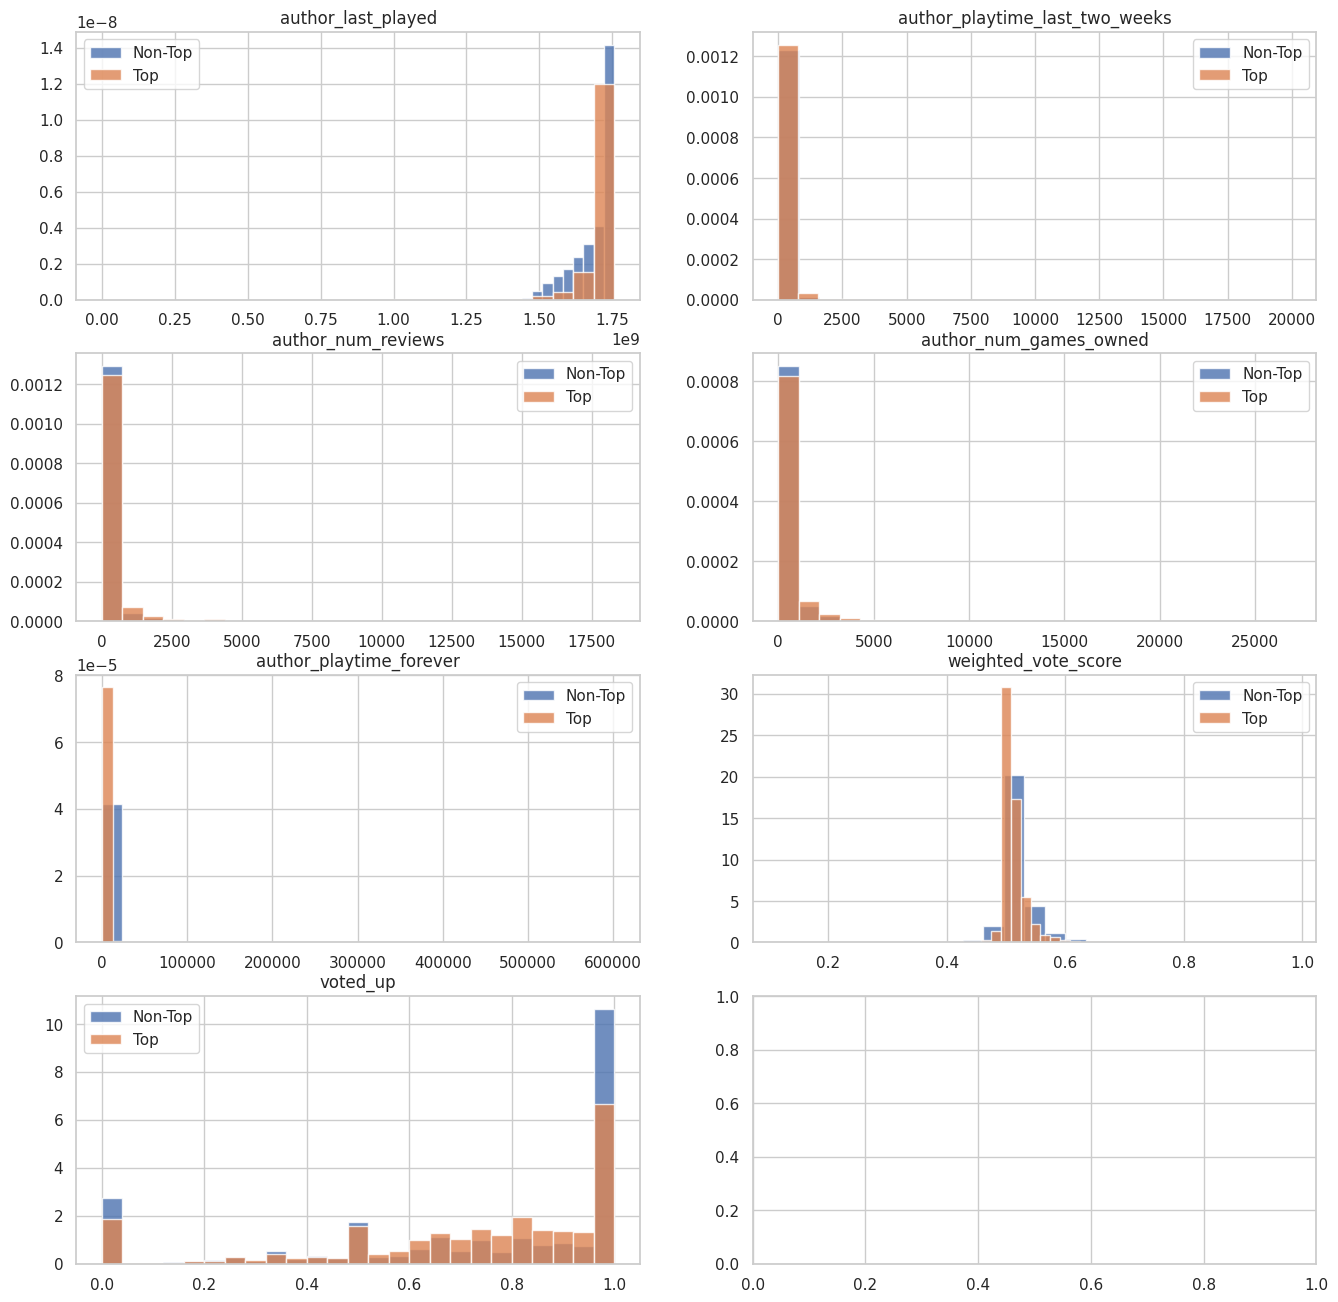

In [70]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))

for i, ax in enumerate(axs.reshape(-1)):

    if i == len(selected_columns):
        break
    column = selected_columns[i]

    developer_selected_metrics[
        developer_selected_metrics['is_top']==0
    ][column].hist(ax=ax, bins=25, 
                                        density=True, alpha=0.8, label='Non-Top')
    developer_selected_metrics[
        developer_selected_metrics['is_top']==1
    ][column].hist(ax=ax, bins=25, 
                                               density=True, alpha=0.8, label='Top')
    ax.set_title(column)
    ax.legend()

#### Micro Aggregation of Metrics

In [71]:
grouped_reviews = df_game_dev_rev[
    df_game_dev_rev['appid'].isin(games_with_reviews)
].groupby('developer_id')

dev_review_metrics = grouped_reviews[statistical_columns].mean()

In [72]:
# Add target variable (is_top)
top_ids = set(top_developers['developer_id'])
dev_review_metrics['is_top'] = dev_review_metrics.index.isin(top_ids).astype(int)

In [73]:
statistics = dict.fromkeys(statistical_columns)

for column in statistical_columns:
    group1 = dev_review_metrics[dev_review_metrics['is_top']==1][column]
    group2 = dev_review_metrics[dev_review_metrics['is_top']==0][column]

    statistics[column] = cohens_d(group1, group2)

In [74]:
pd.Series(statistics).sort_values(ascending=False)

author_last_played                0.41
author_playtime_last_two_weeks    0.30
author_playtime_at_review         0.12
author_num_reviews                0.11
author_num_games_owned            0.08
author_playtime_forever           0.06
votes_funny                      -0.01
comment_count                    -0.04
votes_up                         -0.07
weighted_vote_score              -0.11
dtype: float64

In [75]:
dev_review_selected_metrics = grouped_reviews[[
    'author_last_played',
    'author_playtime_last_two_weeks',
    'author_num_reviews',
    'author_num_games_owned',
    'author_playtime_forever',
    'weighted_vote_score',
    'voted_up'
]].mean()

dev_review_selected_metrics['voted_up'] = dev_review_selected_metrics['voted_up'].astype(np.float64)

In [76]:
selected_columns = dev_review_selected_metrics.columns

In [77]:
# Add target variable (is_top)
top_ids = set(top_developers['developer_id'])
dev_review_selected_metrics['is_top'] = dev_review_selected_metrics.index.isin(top_ids).astype(int)

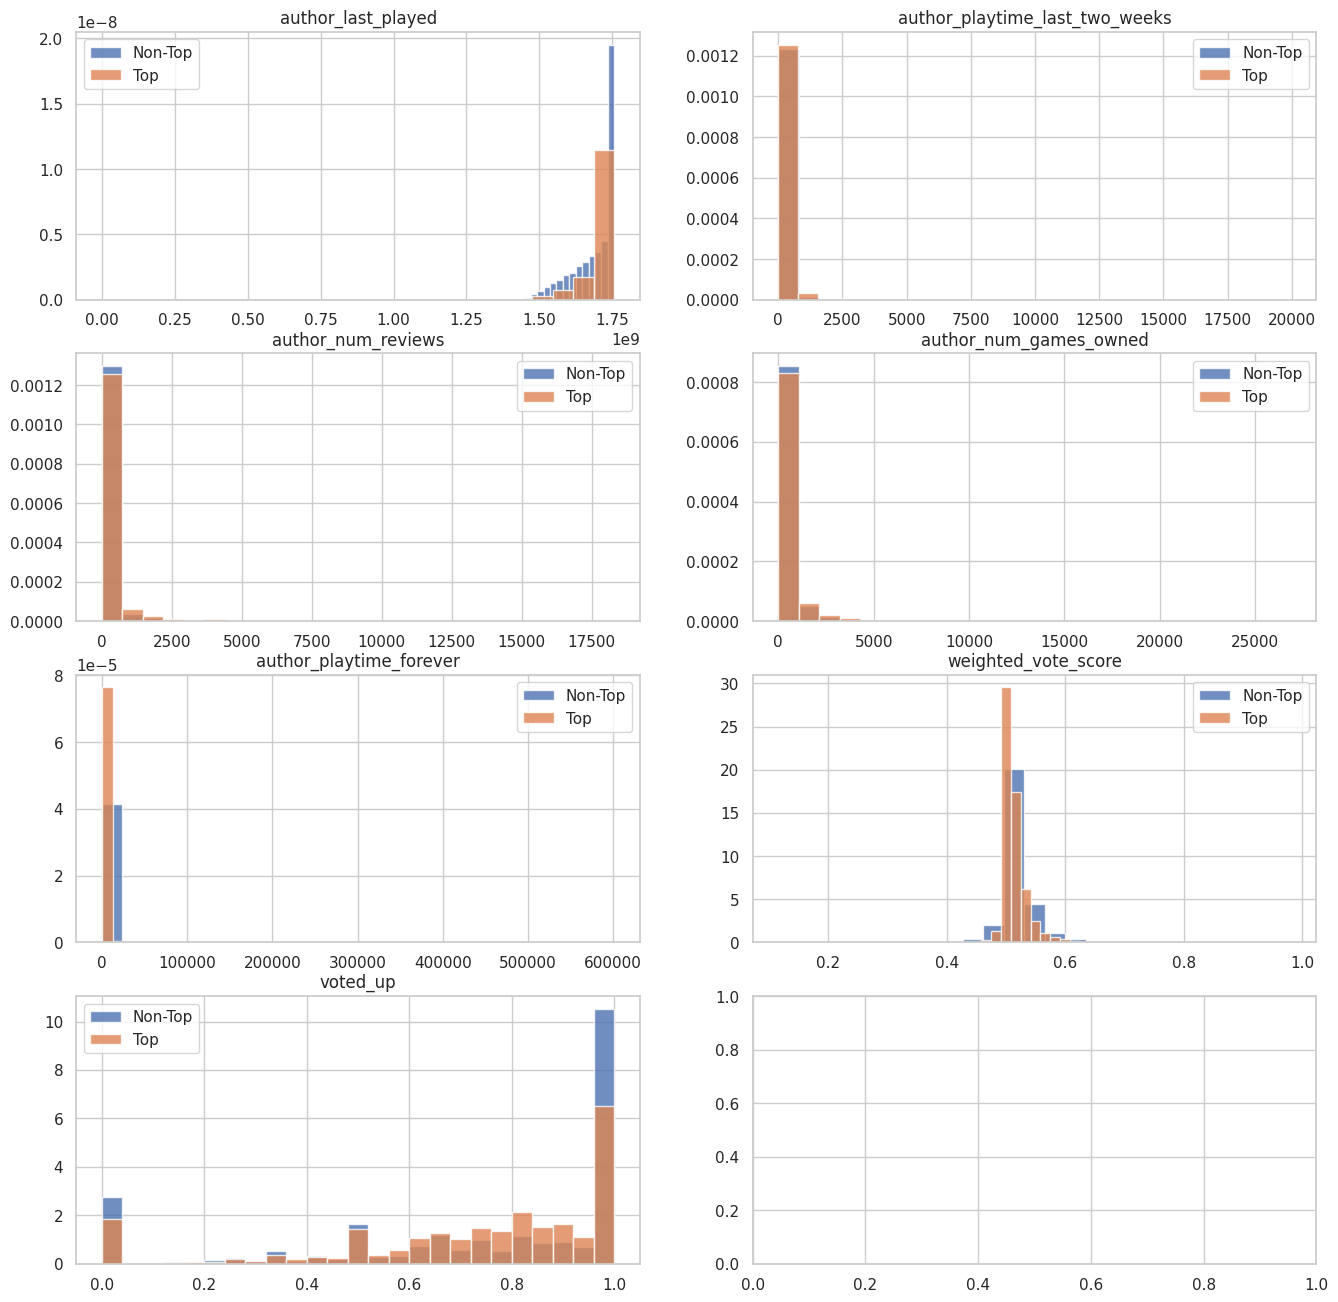

In [78]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))

for i, ax in enumerate(axs.reshape(-1)):

    if i == len(selected_columns):
        break
    column = selected_columns[i]

    dev_review_selected_metrics[
        dev_review_selected_metrics['is_top']==0
    ][column].hist(ax=ax, bins=25, 
                                        density=True, alpha=0.8, label='Non-Top')
    dev_review_selected_metrics[
        dev_review_selected_metrics['is_top']==1
    ][column].hist(ax=ax, bins=25, 
                                               density=True, alpha=0.8, label='Top')
    ax.set_title(column)
    ax.legend()

#### Distribution Difference Analysis:

Let's investigate how features correlate with the group of developer (top developers vs. non-top developers) using Welch's Test ($\alpha=0.05$):

In [79]:
from scipy.stats import ttest_ind
from collections import defaultdict

tests = {'pvalues': [], 'Reject H0': []}


for column in selected_columns:
    pvalue = ttest_ind(
        developer_selected_metrics[
            developer_selected_metrics['is_top'] == 0
        ][column],
        developer_selected_metrics[
            developer_selected_metrics['is_top'] == 1
        ][column],
        equal_var=False,
        alternative='two-sided'
    ).pvalue

    tests['pvalues'].append(pvalue)
    tests['Reject H0'].append(pvalue < 0.025)


for column in selected_columns:
    pvalue = ttest_ind(
        dev_review_selected_metrics[
            dev_review_selected_metrics['is_top'] == 0
        ][column],
        dev_review_selected_metrics[
            dev_review_selected_metrics['is_top'] == 1
        ][column],
        equal_var=False,
        alternative='two-sided'
    ).pvalue

    tests['pvalues'].append(pvalue)
    tests['Reject H0'].append(pvalue < 0.025)

In [80]:
test_results = pd.DataFrame(tests, index=\
    [macro_column + "_macro" for macro_column in selected_columns] + \
    [micro_column + "_micro" for micro_column in selected_columns]
)

print(test_results)

                                      pvalues  Reject H0
author_last_played_macro                 0.00       True
author_playtime_last_two_weeks_macro     0.00       True
author_num_reviews_macro                 0.00       True
author_num_games_owned_macro             0.00       True
author_playtime_forever_macro            0.00       True
weighted_vote_score_macro                0.00       True
voted_up_macro                           0.71      False
author_last_played_micro                 0.00       True
author_playtime_last_two_weeks_micro     0.00       True
author_num_reviews_micro                 0.00       True
author_num_games_owned_micro             0.00       True
author_playtime_forever_micro            0.00       True
weighted_vote_score_micro                0.00       True
voted_up_micro                           0.69      False


#### Examine Correlation Between Features

In [81]:
developer_selected_metrics_correlation_matrix = developer_selected_metrics[selected_columns].corr()
dev_review_selected_metrics_correlation_matrix = dev_review_selected_metrics[selected_columns].corr()

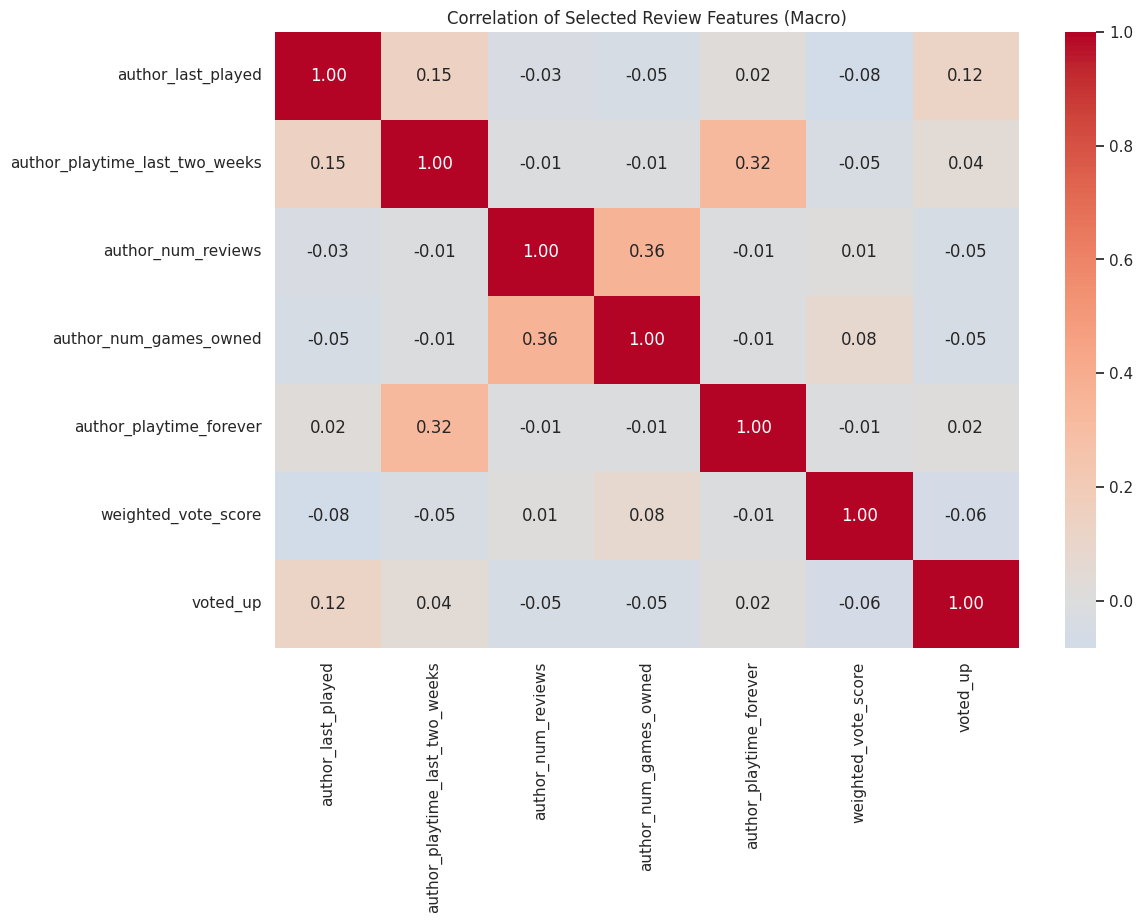

In [82]:
plt.figure(figsize=(12, 8))
sns.heatmap(developer_selected_metrics_correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation of Selected Review Features (Macro)')
plt.show()

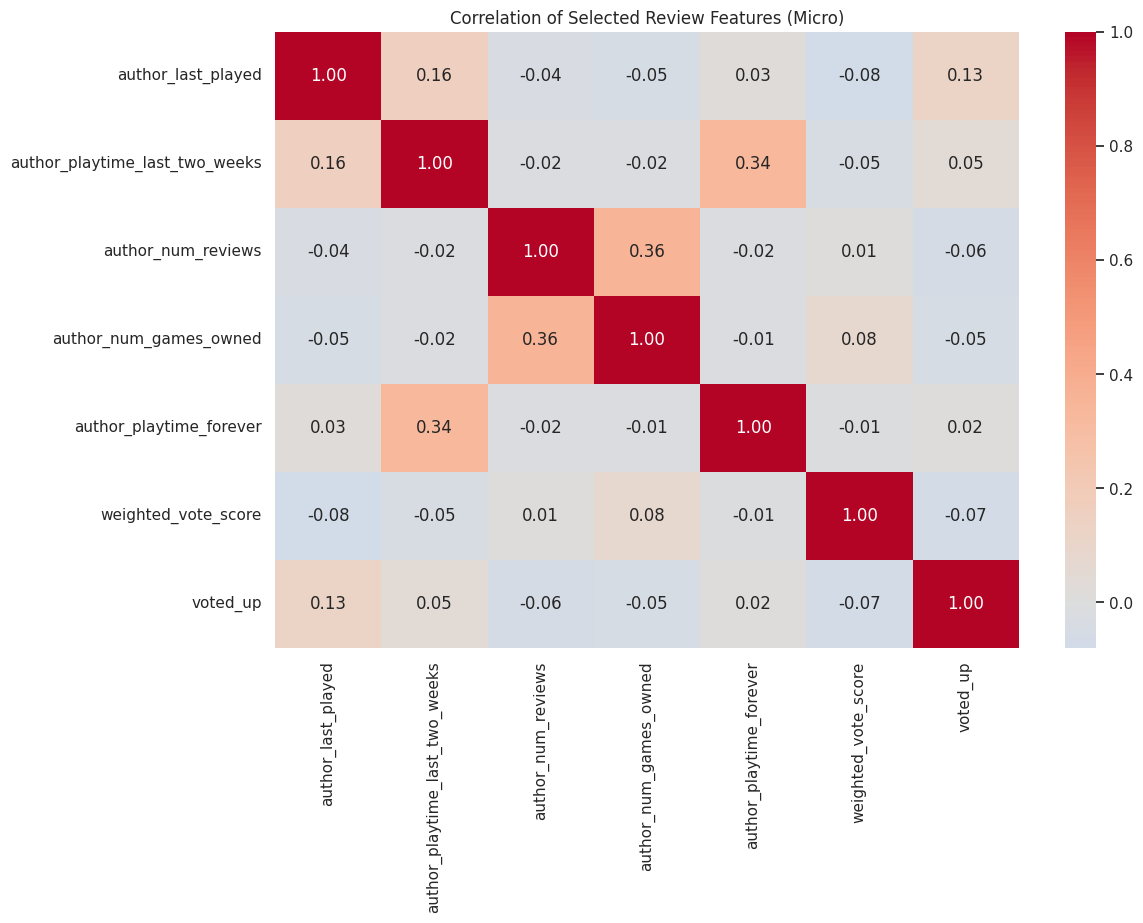

In [83]:
plt.figure(figsize=(12, 8))
sns.heatmap(dev_review_selected_metrics_correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation of Selected Review Features (Micro)')
plt.show()

**Key takeways**:

1. Developers who partner with top publishers produce games that
- have players with significant change in play time (`author_last_played`, `author_playtime_last_two_weeks`, `author_playtime_forever`);
- also have players with differences in number of owned games (`author_num_games_owned`) and number of reviews (`author_num_reviews`);
- receive different helpfulness scores (`weighted_vote_score_macro`).

2. Positive vote ratio is not correlated with group of developer.

3. Macro and micro averaging demonstrate the same result.

### Exploring Application Data for Possible Features

#### Join Category and Genres to Games

In [84]:
df_games_with_cats = df_game_cat.merge(
    df_cat,
    left_on='category_id',
    right_on='id'
).drop(columns=['id', 'category_id']).rename(columns={'name': 'category_name'})

df_games_with_cats.head()

,appid,category_name
0,1313,LAN PvP
1,1313,PvP
2,1313,Family Sharing
3,1313,Multi-player
4,1313,Single-player


In [85]:
df_games_with_genres = df_game_genres.merge(
    df_genres,
    left_on='genre_id',
    right_on='id'
).drop(columns=['id', 'genre_id']).rename(columns={'name': 'genre_name'})

df_games_with_genres.head()

,appid,genre_name
0,1313,Action
1,7800,Action
2,8980,Action
3,8980,RPG
4,11550,Action


In [86]:
len(df_games_with_genres), len(df_games_with_cats)

(303908, 453736)

In [87]:
df_games_full = df_games.merge(
    pd.merge(
        df_games_with_genres,
        df_games_with_cats,
        on='appid'
    ),
    on='appid'
)

In [88]:
df_games_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343787 entries, 0 to 1343786
Data columns (total 32 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   appid                  1343787 non-null  int64         
 1   name                   1343787 non-null  object        
 2   type                   1343787 non-null  object        
 3   is_free                1343787 non-null  bool          
 4   release_date           1343787 non-null  datetime64[ns]
 5   required_age           1343787 non-null  object        
 6   short_description      1343375 non-null  object        
 7   supported_languages    1343340 non-null  object        
 8   header_image           1343787 non-null  object        
 9   background             1343787 non-null  object        
 10  metacritic_score       54117 non-null    float64       
 11  recommendations_total  305161 non-null   float64       
 12  mat_supports_windows   13437

In [89]:
(df_games_full.count() / len(df_games_full)).sort_values(ascending=False)

appid                   1.00
name                    1.00
type                    1.00
is_free                 1.00
release_date            1.00
required_age            1.00
background              1.00
header_image            1.00
mat_supports_linux      1.00
mat_supports_windows    1.00
mat_supports_mac        1.00
created_at              1.00
category_name           1.00
genre_name              1.00
updated_at              1.00
short_description       1.00
supported_languages     1.00
mat_pc_os_min           0.98
mat_pc_memory_min       0.95
mat_pc_processor_min    0.94
mat_pc_graphics_min     0.88
mat_currency            0.84
mat_initial_price       0.84
mat_final_price         0.84
mat_discount_percent    0.84
mat_achievement_count   0.66
mat_pc_os_rec           0.55
mat_pc_memory_rec       0.53
mat_pc_processor_rec    0.52
mat_pc_graphics_rec     0.51
recommendations_total   0.23
metacritic_score        0.04
dtype: float64

#### Hypothesis on Application Features

In [90]:
top_developers = df_pub_dev[df_pub_dev['publisher_id'].isin(top_p_pubs.index)]

In [91]:
game_attrs = df_games_full.groupby('appid').first().reset_index()

# Select relevant columns for game attributes
game_cols = ['appid', 'is_free', 'mat_initial_price', 'mat_final_price',
             'mat_discount_percent', 'mat_achievement_count',
             'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux',
            'release_date', 'supported_languages']
game_attrs = game_attrs[game_cols].copy()

In [92]:
dev_games = pd.merge(df_game_dev, game_attrs, on='appid', how='left')

In [93]:
dev_games['release_date'] = pd.to_datetime(dev_games['release_date'], errors='coerce')

# Get the current year for reference
current_year = 2025

# Total games per developer with years since first release
dev_stats = dev_games.groupby('developer_id').agg(
    total_games=('appid', 'count'),
    free_games=('is_free', 'sum'),
    avg_initial_price=('mat_initial_price', 'mean'),
    avg_discount_percent=('mat_discount_percent', 'mean'),
    avg_achievement_count=('mat_achievement_count', 'mean'),
    avg_extra_platform_support=(
        'mat_supports_linux', 
        lambda x: (x + dev_games.loc[x.index, 'mat_supports_mac']).mean()
    ),
    avg_languages=('supported_languages', lambda x: x.dropna().apply(
        lambda text: len(str(text).split(','))
    ).mean()),
    max_languages=('supported_languages', lambda x: x.dropna().apply(
        lambda text: len(str(text).split(','))
    ).max()),
    # Years since first release
    years_past_first_release=('release_date', lambda x: current_year - x.min().year),
).reset_index()

dev_stats['years_past_first_release'] = dev_stats['years_past_first_release'].fillna(0)

# Add release frequency (games per year)
dev_stats['release_frequency'] = dev_stats['total_games'] / (dev_stats['years_past_first_release'] + 1)  # +1 to avoid division by zero

# Compute percent_free
dev_stats['percent_free'] = (dev_stats['free_games'] / dev_stats['total_games']).astype(np.float64)

In [94]:
# Compute genre diversity per developer
genre_dev = pd.merge(
    df_games_full[['appid', 'genre_name']].drop_duplicates(),
    df_game_dev,
    on='appid'
)
genre_counts = genre_dev.groupby('developer_id')['genre_name'].nunique().reset_index()
genre_counts.columns = ['developer_id', 'genre_count']

# Merge with dev_stats
dev_stats = pd.merge(dev_stats, genre_counts, on='developer_id', how='left')
# Fill NaN genre_count with 0 for developers with no genre info
dev_stats['genre_count'] = dev_stats['genre_count'].fillna(0)

In [95]:
# Compute category diversity per developer
cat_dev = pd.merge(
    df_games_full[['appid', 'category_name']].drop_duplicates(),
    df_game_dev,
    on='appid'
)
cat_counts = cat_dev.groupby('developer_id')['category_name'].nunique().reset_index()
cat_counts.columns = ['developer_id', 'category_count']

# Merge with dev_stats
dev_stats = pd.merge(dev_stats, cat_counts, on='developer_id', how='left')
# Fill NaN genre_count with 0 for developers with no genre info
dev_stats['category_count'] = dev_stats['category_count'].fillna(0)

In [96]:
# Add target variable (is_top)
top_ids = set(top_developers['developer_id'])
dev_stats['is_top'] = dev_stats['developer_id'].isin(top_ids).astype(int)

In [97]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = group1.mean(), group2.mean()
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (mean1 - mean2) / pooled_std

In [98]:
# Compute Cohen's d for each feature
features = ['avg_initial_price', 'percent_free', 'avg_extra_platform_support',
            'avg_achievement_count', 'genre_count', 'avg_discount_percent',
            'category_count', 'years_past_first_release', 'release_frequency',
           'avg_languages', 'max_languages']
d_values = {}
for feat in features:
    top_vals = dev_stats[dev_stats['is_top']==1][feat].dropna()
    non_top_vals = dev_stats[dev_stats['is_top']==0][feat].dropna()
    if len(top_vals) > 0 and len(non_top_vals) > 0:
        d = cohens_d(top_vals, non_top_vals)
        d_values[feat] = d
    else:
        d_values[feat] = np.nan
cohen_d_series = pd.Series(d_values, name='Cohen_d')
print("Cohen's d (positive means top developers have higher values):")
print(cohen_d_series.sort_values(ascending=False))

Cohen's d (positive means top developers have higher values):
avg_discount_percent          0.84
category_count                0.61
years_past_first_release      0.60
max_languages                 0.18
avg_initial_price             0.14
avg_languages                 0.13
avg_achievement_count         0.11
release_frequency             0.07
genre_count                   0.05
avg_extra_platform_support   -0.00
percent_free                 -0.34
Name: Cohen_d, dtype: float64


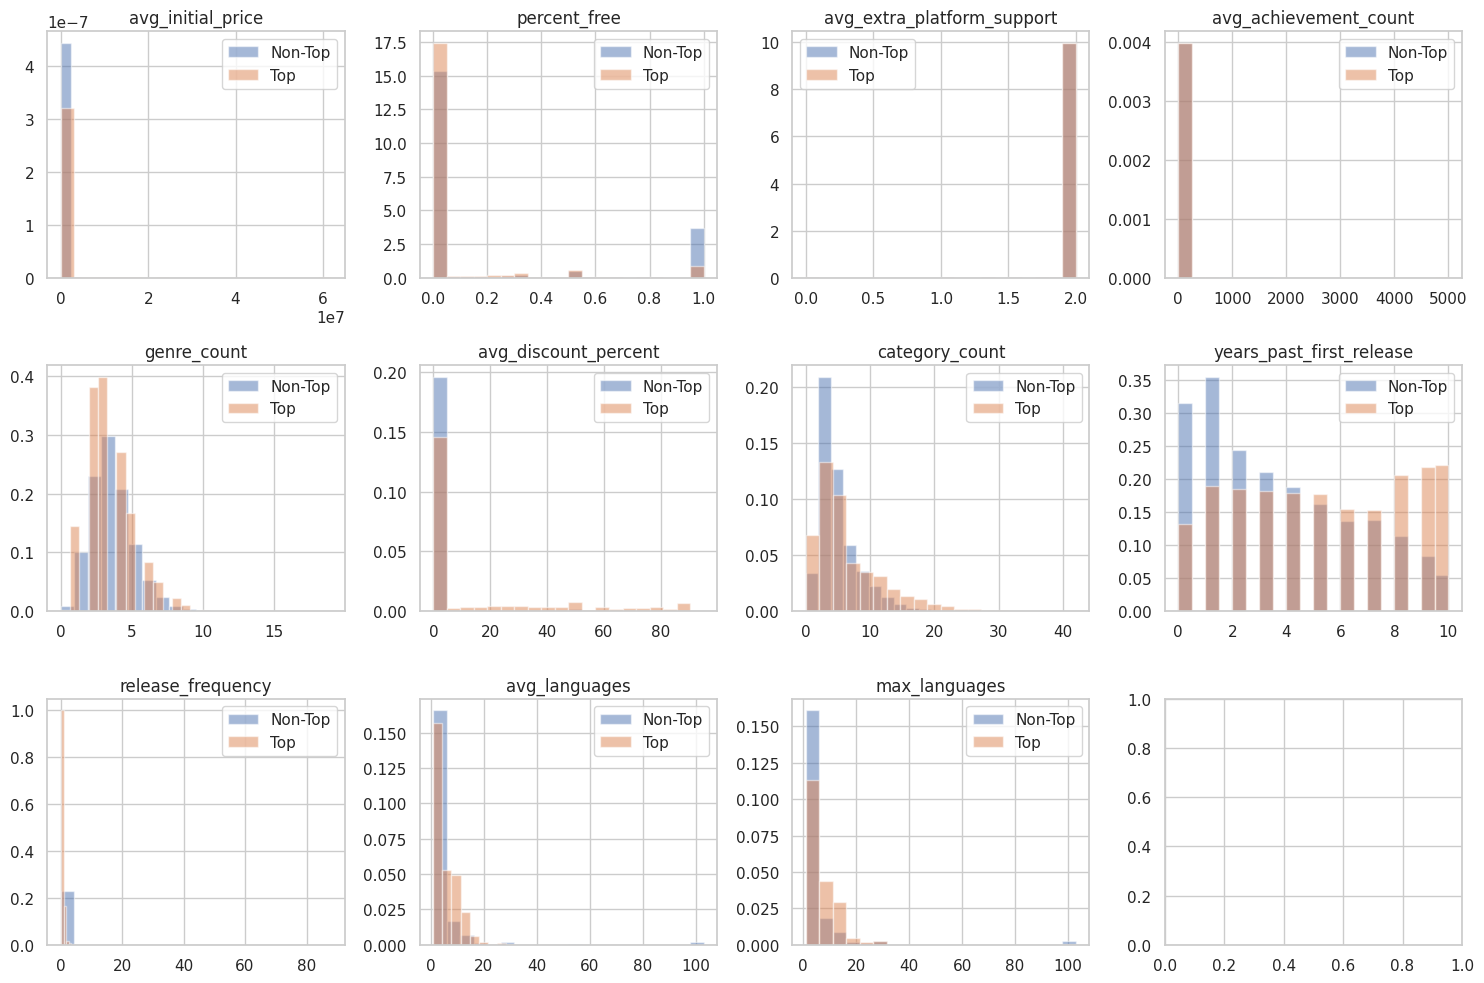

In [99]:
# Plot distributions for each feature
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()
for i, feat in enumerate(features):
    ax = axes[i]
    top_vals = dev_stats[dev_stats['is_top']==1][feat].dropna()
    non_top_vals = dev_stats[dev_stats['is_top']==0][feat].dropna()
    ax.hist(non_top_vals, bins=20, alpha=0.5, label='Non-Top', density=True)
    ax.hist(top_vals, bins=20, alpha=0.5, label='Top', density=True)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

In [100]:
# Perform t-tests (two-sided, equal variance) for each feature
from scipy.stats import ttest_ind

ttest_results = []
for feat in features:
    top_vals = dev_stats[dev_stats['is_top']==1][feat].dropna()
    non_top_vals = dev_stats[dev_stats['is_top']==0][feat].dropna()
    if len(top_vals) > 1 and len(non_top_vals) > 1:
        stat, p = ttest_ind(non_top_vals, top_vals, equal_var=False, alternative='two-sided')
        reject = p < 0.025
        ttest_results.append({'feature': feat, 'pvalue': p, 'Reject H0': reject})
    else:
        ttest_results.append({'feature': feat, 'pvalue': np.nan, 'Reject H0': False})
ttest_df = pd.DataFrame(ttest_results).set_index('feature')
print(ttest_df)

                            pvalue  Reject H0
feature                                      
avg_initial_price             0.00       True
percent_free                  0.00       True
avg_extra_platform_support    0.96      False
avg_achievement_count         0.00       True
genre_count                   0.01       True
avg_discount_percent          0.00       True
category_count                0.00       True
years_past_first_release      0.00       True
release_frequency             0.00       True
avg_languages                 0.00       True
max_languages                 0.00       True


In [101]:
dev_application_features_correlation_matrix = dev_stats[features].corr()

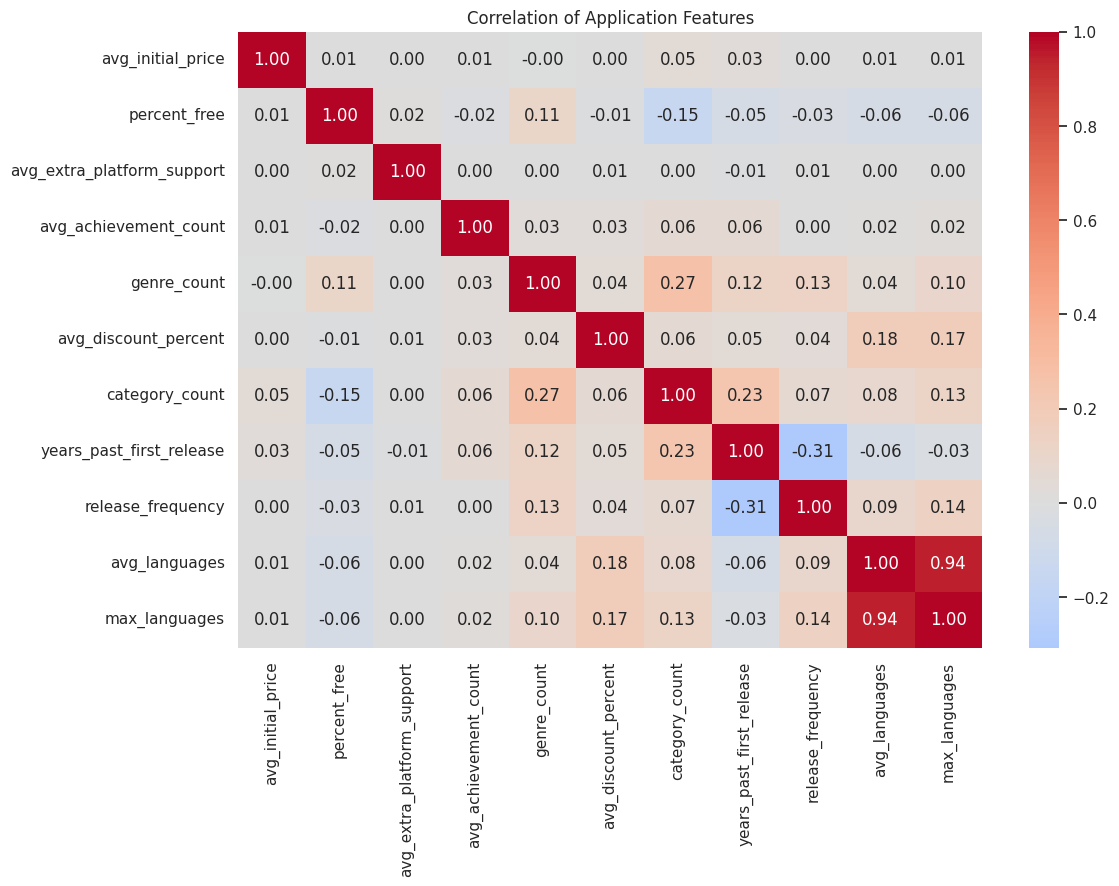

In [102]:
plt.figure(figsize=(12, 8))
sns.heatmap(dev_application_features_correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation of Application Features')
plt.show()

**Key takeways**:

1. Developers who partner with top publishers produce games that
- have different mean starting price (`avg_initial_price`);
- have different mean number of achievements (`avg_achievement_count`);
- have different number of categories (`category_count`) as well as genres (`genre_count`);
- differ in percent of free games (`percent_free`) and average discount (`avg_discount_percent`).
- differ in frequency of releases and years from the first release (`release_frequency`, `years_past_first_release`).
- differ in mean and max number of supported languages (`avg_languages`, `max_languages`).

2. Average extra platform support (`avg_extra_platform_support`) was not found to correlate with group of developer.

3. Maximum supported languages count (`max_languages`) does not itself carry too much information and can be replaced with `avg_languages` fully.

### Analyze Missing Values

In [103]:
# Count developers with complete game data (no missing values in dev_stats)

# Identify columns to check for missing values (exclude developer_id and derived columns)
game_feature_cols = ['avg_initial_price', 'percent_free', 'avg_extra_platform_support',
                     'avg_achievement_count', 'genre_count', 'avg_discount_percent',
                     'category_count', 'years_past_first_release', 'release_frequency',
                     'avg_languages']

# Developers with complete game data (no missing values in these columns)
devs_with_complete_game_data = dev_stats.dropna(subset=game_feature_cols)
complete_game_count = len(devs_with_complete_game_data)
total_devs_in_stats = dev_stats['developer_id'].nunique()

print(f"Developers with complete game data among developers with games: {complete_game_count:,} / {total_devs_in_stats:,} = {complete_game_count/total_devs_in_stats*100:.1f}%")

Developers with complete game data among developers with games: 33,620 / 70,219 = 47.9%


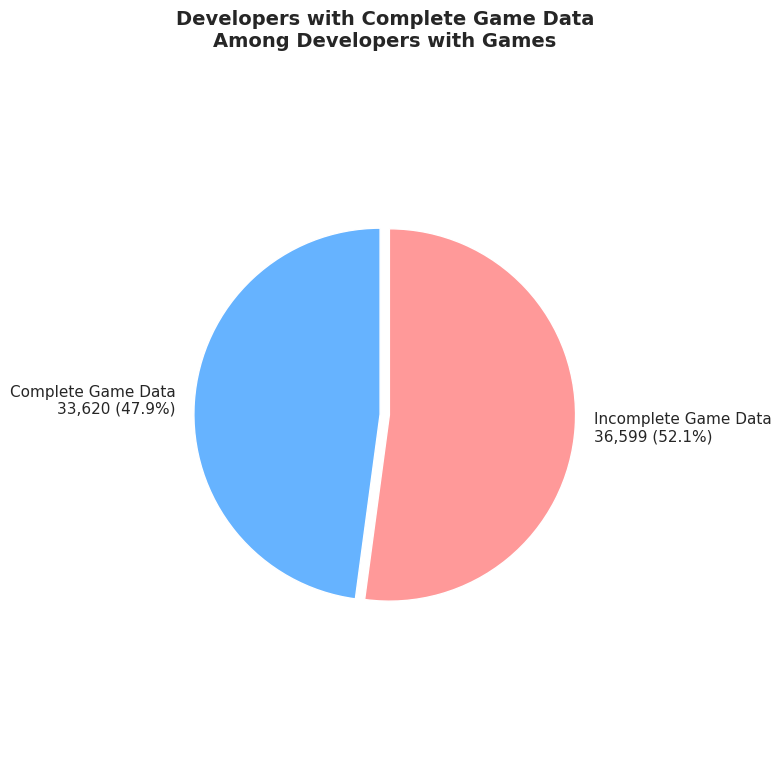

In [104]:
# Pie chart - Developers with complete game data vs incomplete
plt.figure(figsize=(8, 8))
incomplete_game_count = total_devs_in_stats - complete_game_count
categories = ['Complete Game Data', 'Incomplete Game Data']
counts = [complete_game_count, incomplete_game_count]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0)

plt.pie(counts, labels=[f'{cat}\n{count:,} ({count/total_devs_in_stats*100:.1f}%)' 
                        for cat, count in zip(categories, counts)],
        colors=colors, explode=explode, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Developers with Complete Game Data\nAmong Developers with Games', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [105]:
# Merge developers with both review data and game data

# Get developers with review data (from earlier calculation)
# devs_with_reviews = set of developer_ids with sampled reviews
games_with_reviews = df_game_dev_rev.groupby('appid')['recommendationid'].nunique()
games_with_reviews = games_with_reviews[games_with_reviews > 0].index
devs_with_reviews = set(df_game_dev_rev[df_game_dev_rev['appid'].isin(games_with_reviews)]['developer_id'].unique())

# Get developers with game data (from dev_stats)
devs_with_game_data = set(dev_stats['developer_id'])

# Find intersection
devs_with_both = devs_with_game_data.intersection(devs_with_reviews)
devs_with_game_only = devs_with_game_data - devs_with_reviews
devs_with_review_only = devs_with_reviews - devs_with_game_data  # Should be empty if relationships are correct

# Total unique developers across both sources
total_developers_with_data = len(devs_with_game_data.union(devs_with_reviews))

print(f"Developers with game data only: {len(devs_with_game_only):,}")
print(f"Developers with review data only: {len(devs_with_review_only):,}")
print(f"Developers with BOTH game and review data: {len(devs_with_both):,}")
print(f"Total developers with any data: {total_developers_with_data:,}")

Developers with game data only: 16,939
Developers with review data only: 0
Developers with BOTH game and review data: 53,280
Total developers with any data: 70,219


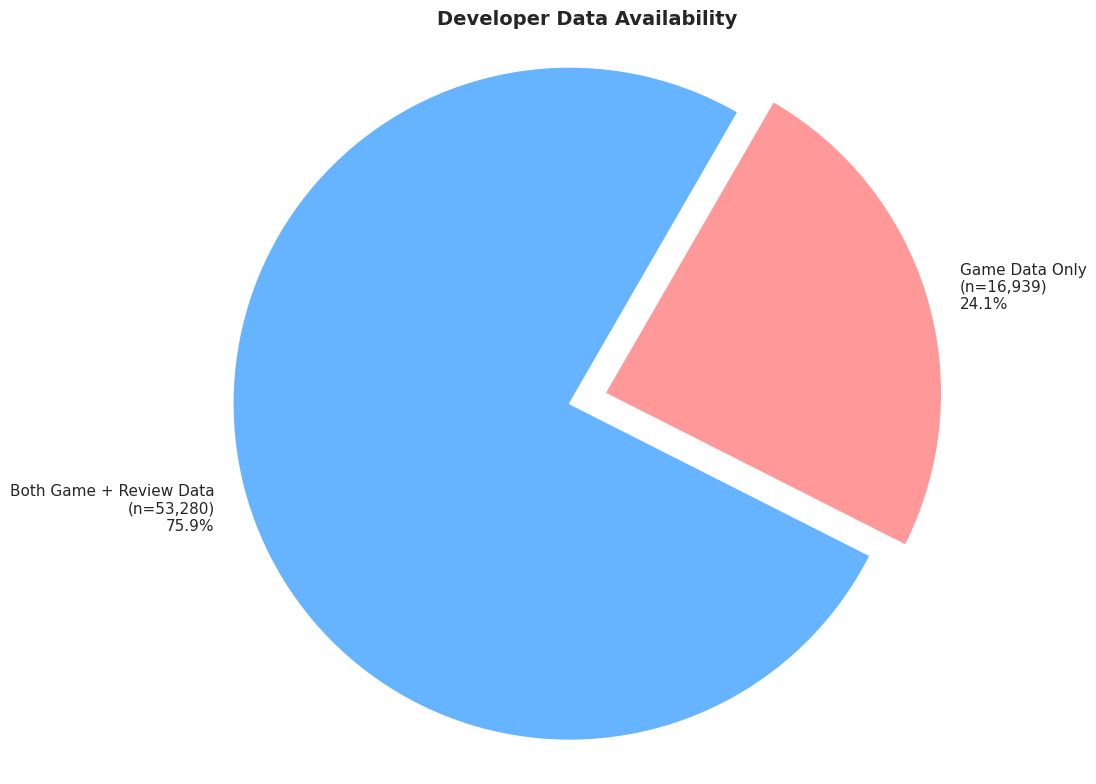

In [106]:
# Pie chart - Developers by data availability
plt.figure(figsize=(10, 8))
categories = [
    f'Both Game + Review Data\n(n={len(devs_with_both):,})',
    f'Game Data Only\n(n={len(devs_with_game_only):,})'
]
counts = [len(devs_with_both), len(devs_with_game_only)]
colors = ['#66b3ff', '#ff9999']
explode = (0.08, 0.03)

plt.pie(counts, labels=[f'{cat}\n{count/total_developers_with_data*100:.1f}%' 
                        for cat, count in zip(categories, counts)],
        colors=colors, explode=explode, startangle=60,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Developer Data Availability', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [107]:
# Among developers with BOTH traits, what proportion are top developers?

# Get top developers list
top_dev_ids = set(top_developers['developer_id'])  # From your earlier definition

# Developers with both traits that are top
top_devs_with_both = devs_with_both.intersection(top_dev_ids)
non_top_devs_with_both = devs_with_both - top_dev_ids

print(f"Top developers with both traits: {len(top_devs_with_both):,}")
print(f"Non-top developers with both traits: {len(non_top_devs_with_both):,}")
print(f"Total developers with both traits: {len(devs_with_both):,}")
print(f"Top developers as % of both-traits group: {len(top_devs_with_both)/len(devs_with_both)*100:.1f}%")

Top developers with both traits: 3,845
Non-top developers with both traits: 49,435
Total developers with both traits: 53,280
Top developers as % of both-traits group: 7.2%


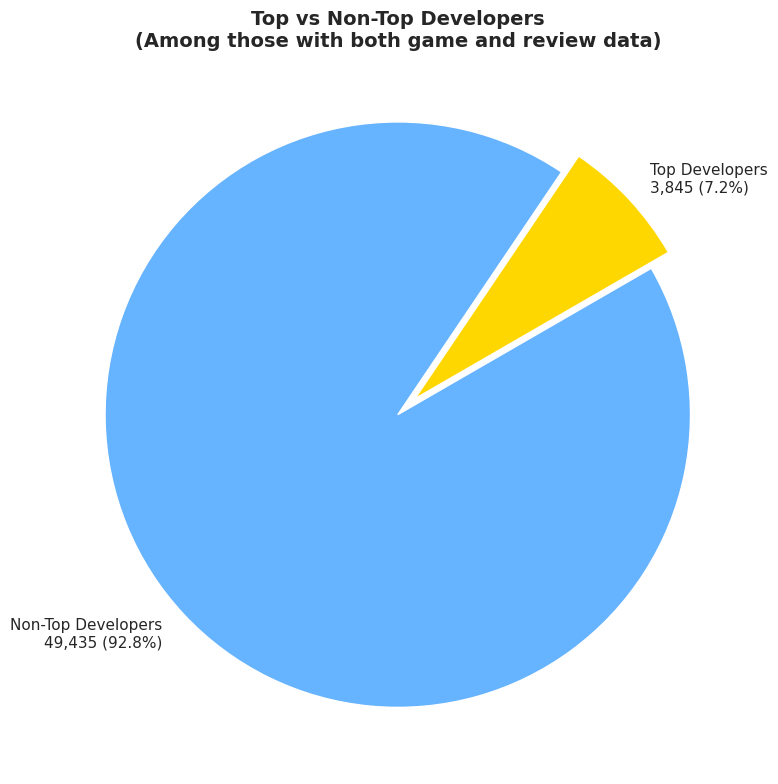

In [108]:
# Pie chart - Top vs Non-top among developers with both traits
plt.figure(figsize=(8, 8))
categories = ['Top Developers', 'Non-Top Developers']
counts = [len(top_devs_with_both), len(non_top_devs_with_both)]
colors = ['#ffd700', '#66b3ff']  # Gold for top, blue for non-top
explode = (0.08, 0)

plt.pie(counts, labels=[f'{cat}\n{count:,} ({count/len(devs_with_both)*100:.1f}%)' 
                        for cat, count in zip(categories, counts)],
        colors=colors, explode=explode, startangle=30,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title('Top vs Non-Top Developers\n(Among those with both game and review data)', 
          fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

Developers with complete data: 33,620
  • Top developers with complete data: 2,743
  • Non-top developers with complete data: 30,877
Top developers as % of complete-data group: 8.2%


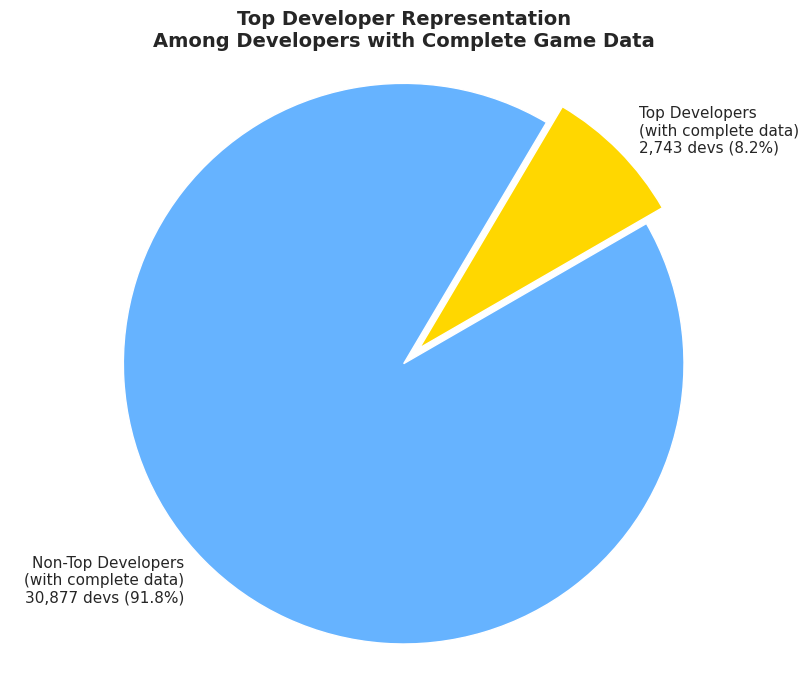

In [109]:
# Pie chart - Top developers vs non-top developers among those with complete data

# Get developers with complete game data (from earlier)
# devs_with_complete_game_data contains developers with no missing values in game features
complete_dev_ids = set(devs_with_complete_game_data['developer_id'])

# Get top developers list
top_dev_ids = set(top_developers['developer_id'])  # From your earlier definition

# Find top developers with complete data
top_devs_complete = complete_dev_ids.intersection(top_dev_ids)
non_top_devs_complete = complete_dev_ids - top_dev_ids

complete_count = len(complete_dev_ids)
top_complete_count = len(top_devs_complete)
non_top_complete_count = len(non_top_devs_complete)

print(f"Developers with complete data: {complete_count:,}")
print(f"  • Top developers with complete data: {top_complete_count:,}")
print(f"  • Non-top developers with complete data: {non_top_complete_count:,}")
print(f"Top developers as % of complete-data group: {top_complete_count/complete_count*100:.1f}%")

# Create pie chart
plt.figure(figsize=(9, 8))
categories = [
    f'Top Developers\n(with complete data)',
    f'Non-Top Developers\n(with complete data)'
]
counts = [top_complete_count, non_top_complete_count]
colors = ['#ffd700', '#66b3ff']  # Gold for top, blue for non-top
explode = (0.08, 0)

# Calculate percentages for labels
percentages = [f'{count/complete_count*100:.1f}%' for count in counts]
labels = [f'{cat}\n{count:,} devs ({perc})' 
          for cat, count, perc in zip(categories, counts, percentages)]

plt.pie(counts, 
        labels=labels,
        colors=colors, 
        explode=explode, 
        startangle=30,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1},
        textprops={'fontsize': 11})
plt.title('Top Developer Representation\nAmong Developers with Complete Game Data', 
          fontsize=14, fontweight='bold')
plt.axis('equal')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# Cell: Compare with overall top developer proportion
total_top_devs = len(top_dev_ids)
total_all_devs = len(df_dev['id'].unique())  # or whatever your total developers count is

## Second Business Objective

**Business objective**: 

*Create a scoring system that ranks emerging developers (first release
within 3 years) according to similarity to the successful partnership patterns identified.*

EDA Steps:
- What are the proportions of emerging developers among all developers and among developers that have partnership with major publishers?

### Emerging Developers Proportions

In [110]:
df_games_with_devs = df_games.merge(
    df_game_dev.merge(
        df_dev,
        left_on='developer_id',
        right_on='id'
    ).drop(columns=['id']).rename(columns={'name': 'developer_name'}),
    on='appid'
)

In [111]:
df_games_with_devs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114558 entries, 0 to 114557
Data columns (total 32 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appid                  114558 non-null  int64         
 1   name                   114558 non-null  object        
 2   type                   114558 non-null  object        
 3   is_free                114558 non-null  bool          
 4   release_date           114558 non-null  datetime64[ns]
 5   required_age           114558 non-null  object        
 6   short_description      114509 non-null  object        
 7   supported_languages    114449 non-null  object        
 8   header_image           114558 non-null  object        
 9   background             114558 non-null  object        
 10  metacritic_score       3092 non-null    float64       
 11  recommendations_total  19425 non-null   float64       
 12  mat_supports_windows   114558 non-null  bool

In [112]:
# Convert release_date to datetime and filter valid dates
df_games_with_devs['release_date'] = pd.to_datetime(df_games_with_devs['release_date'], errors='coerce')
df_games_with_devs_valid = df_games_with_devs.dropna(subset=['release_date'])

In [113]:
# Get earliest release date for each developer
developer_first_release = df_games_with_devs_valid.groupby('developer_id')['release_date'].min().reset_index()
developer_first_release.columns = ['developer_id', 'first_release_date']

In [114]:
# Filter developers with first release within 2022-01-01 < x < 2026-01-01
emergence_mask = (developer_first_release['first_release_date'] > '2022-01-01') & \
       (developer_first_release['first_release_date'] < '2026-01-01')
df_devs_in_period = developer_first_release[emergence_mask]

In [115]:
# Merge with original to get developer names and their apps
df_emerging_devs = pd.merge(df_devs_in_period, df_games_with_devs[['developer_id', 'developer_name']].drop_duplicates(),
                     on='developer_id', how='left')

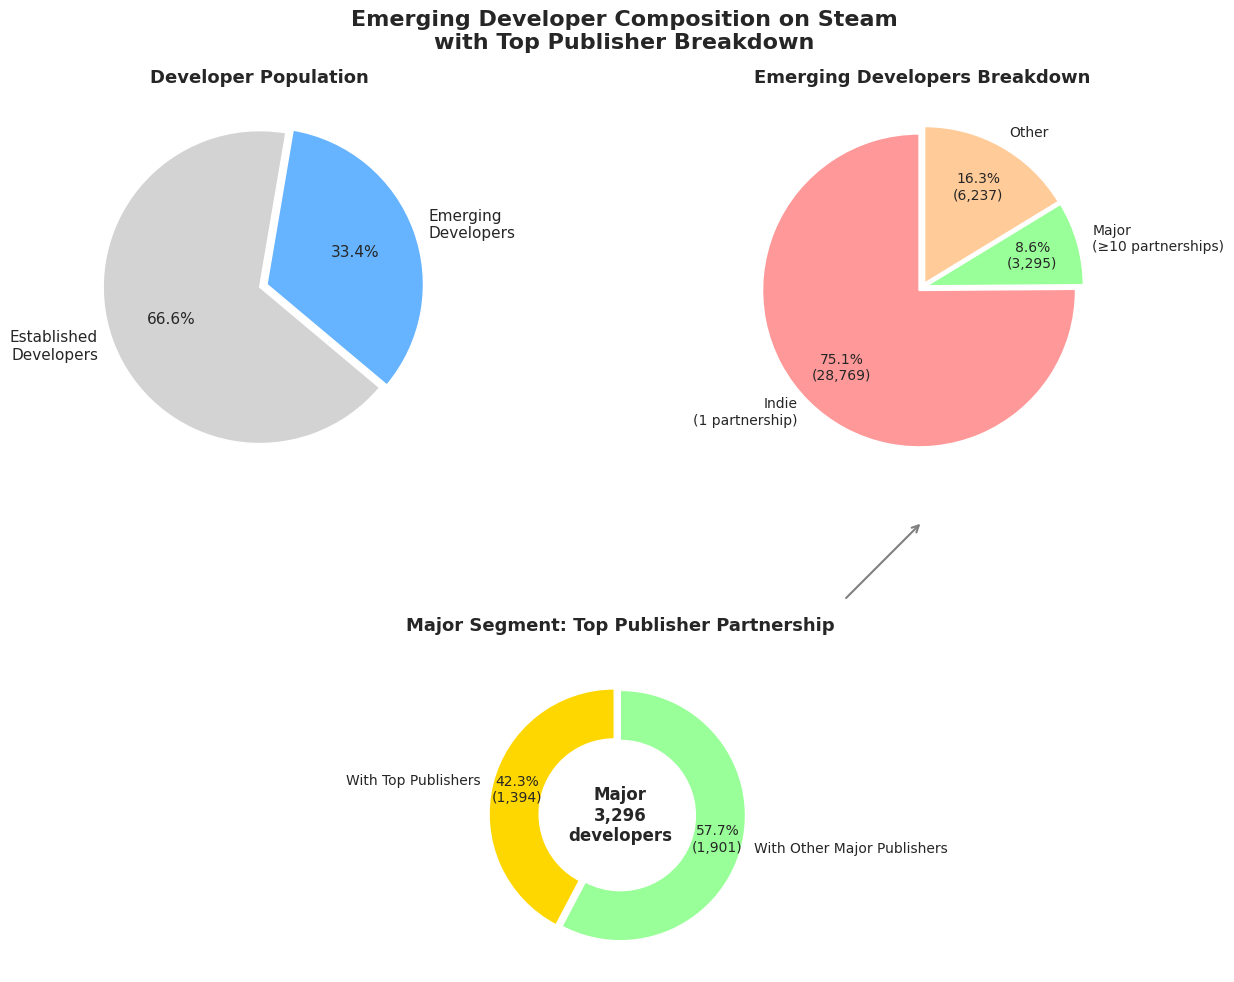

EMERGING DEVELOPERS DETAILED BREAKDOWN WITH TOP PUBLISHERS
Category                                   Count   % of Emerging   % of Total
----------------------------------------------------------------------------
Total Emerging                            38,302          100.0%        33.4%
  • Indie (1 partnership)                 28,769           75.1%        25.1%
  • Major (≥10 partnerships)               3,296            8.6%         2.9%
      ▪ With Top Publishers                1,394            3.6%         1.2%
      ▪ With Other Major                   1,902            5.0%         1.7%
  • Other                                  6,237           16.3%         5.4%
----------------------------------------------------------------------------
Total Developers                         114,558              -       100.0%

KEY INSIGHT:
  • 1,394 emerging developers (3.6%) already work with top publishers
  • These represent 42.3% of major emerging developers
  • The target pool: 36,9

In [116]:
# Comprehensive emerging developers breakdown with top publisher layer

# Calculate the base segments
emerging_total = len(df_emerging_devs)
total_devs = len(df_games_with_devs)
established_count = total_devs - emerging_total

# Indie developers among emerging
emerging_indie = df_emerging_devs[
    df_emerging_devs['developer_name'].isin(indie_devs['developer_name'])
].shape[0]

# Developers with 10+ partnerships among emerging (major publishers)
emerging_major_all = df_emerging_devs[
    df_emerging_devs['developer_id'].isin(df_pub_dev_filtered['developer_id'])
].shape[0]

# Among major, identify those working with TOP publishers (filtered_ranks)
top_pub_ids = set(top_p_pubs.index)  # Your top publishers by volume
df_pub_dev_top = df_pub_dev[df_pub_dev['publisher_id'].isin(top_pub_ids)]
emerging_top = df_emerging_devs[
    df_emerging_devs['developer_id'].isin(df_pub_dev_top['developer_id'])
].shape[0]

# Major but NOT top (still ≥10 partnerships but not with top publishers)
emerging_major_non_top = emerging_major_all - emerging_top

# Remaining emerging developers (neither indie nor major)
emerging_other = emerging_total - emerging_indie - emerging_major_all

# Create figure with nested structure
fig = plt.figure(figsize=(14, 10))

# Use gridspec for more control
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.2], height_ratios=[1, 0.8])

# --- Main pie: Emerging vs Established (top left) ---
ax1 = fig.add_subplot(gs[0, 0])
wedges1, texts1, autotexts1 = ax1.pie(
    [emerging_total, established_count],
    labels=['Emerging\nDevelopers', 'Established\nDevelopers'],
    colors=['#66b3ff', '#d3d3d3'],
    autopct='%1.1f%%',
    startangle=320,
    explode=(0.05, 0),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    textprops={'fontsize': 11}
)
ax1.set_title('Developer Population', fontsize=13, fontweight='bold')

# --- Sub-pie: Breakdown of emerging developers (top right) ---
ax2 = fig.add_subplot(gs[0, 1])
colors_sub = ['#ff9999', '#99ff99', '#ffcc99']
wedges2, texts2, autotexts2 = ax2.pie(
    [emerging_indie, emerging_major_all, emerging_other],
    labels=[
        f'Indie\n(1 partnership)',
        f'Major\n(≥10 partnerships)',
        f'Other'
    ],
    colors=colors_sub,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct*emerging_total/100):,})',
    pctdistance=0.7,
    startangle=90,
    explode=(0.03, 0.03, 0.03),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    textprops={'fontsize': 10}
)
ax2.set_title('Emerging Developers Breakdown', fontsize=13, fontweight='bold')

# --- Nested pie: Major segment breakdown (bottom spanning both columns) ---
ax3 = fig.add_subplot(gs[1, :])
if emerging_major_all > 0:
    # Create donut chart for major segment breakdown
    major_labels = ['With Top Publishers', 'With Other Major Publishers']
    major_counts = [emerging_top, emerging_major_non_top]
    major_colors = ['#ffd700', '#99ff99']  # Gold for top, light green for other major
    
    # Donut chart
    wedges3, texts3, autotexts3 = ax3.pie(
        major_counts,
        labels=major_labels,
        colors=major_colors,
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct*emerging_major_all/100):,})',
        startangle=90,
        explode=(0.05, 0),
        wedgeprops={'edgecolor': 'white', 'linewidth': 1, 'width': 0.4},
        textprops={'fontsize': 10},
        pctdistance=0.8
    )
    
    # Add center text
    ax3.text(0, 0, f'Major\n{emerging_major_all:,}\ndevelopers', 
             ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Add title and connection arrows
    ax3.set_title('Major Segment: Top Publisher Partnership', 
                  fontsize=13, fontweight='bold', pad=20)
    
    # Draw arrows from major segment in ax2 to this donut
    if len(wedges2) > 1:  # If major segment exists
        # Get the position of the major wedge in ax2
        major_wedge = wedges2[1]  # Assuming major is second wedge (index 1)
        
        # Add connecting lines/annotations
        ax2.annotate('', xy=(0.5, -0.1), xytext=(0.3, -0.3),
                     xycoords='axes fraction', textcoords='axes fraction',
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
                     annotation_clip=False)
else:
    ax3.text(0.5, 0.5, 'No Major Developers\nin Emerging Group', 
             ha='center', va='center', fontsize=12, transform=ax3.transAxes)
    ax3.set_title('Major Segment Analysis', fontsize=13, fontweight='bold')

plt.suptitle('Emerging Developer Composition on Steam\nwith Top Publisher Breakdown', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Print detailed statistics
print("=" * 70)
print("EMERGING DEVELOPERS DETAILED BREAKDOWN WITH TOP PUBLISHERS")
print("=" * 70)
print(f"{'Category':<35} {'Count':>12} {'% of Emerging':>15} {'% of Total':>12}")
print("-" * 76)
print(f"{'Total Emerging':<35} {emerging_total:>12,} {100.0:>14.1f}% {emerging_total/total_devs*100:>11.1f}%")
print(f"{'  • Indie (1 partnership)':<35} {emerging_indie:>12,} {emerging_indie/emerging_total*100:>14.1f}% {emerging_indie/total_devs*100:>11.1f}%")
print(f"{'  • Major (≥10 partnerships)':<35} {emerging_major_all:>12,} {emerging_major_all/emerging_total*100:>14.1f}% {emerging_major_all/total_devs*100:>11.1f}%")
print(f"{'      ▪ With Top Publishers':<35} {emerging_top:>12,} {emerging_top/emerging_total*100:>14.1f}% {emerging_top/total_devs*100:>11.1f}%")
print(f"{'      ▪ With Other Major':<35} {emerging_major_non_top:>12,} {emerging_major_non_top/emerging_total*100:>14.1f}% {emerging_major_non_top/total_devs*100:>11.1f}%")
print(f"{'  • Other':<35} {emerging_other:>12,} {emerging_other/emerging_total*100:>14.1f}% {emerging_other/total_devs*100:>11.1f}%")
print("-" * 76)
print(f"{'Total Developers':<35} {total_devs:>12,} {'-':>14} {100.0:>11.1f}%")
print("=" * 70)

# Key insight
print(f"\nKEY INSIGHT:")
print(f"  • {emerging_top:,} emerging developers ({emerging_top/emerging_total*100:.1f}%) already work with top publishers")
print(f"  • These represent {emerging_top/emerging_major_all*100:.1f}% of major emerging developers")
print(f"  • The target pool: {emerging_major_non_top + emerging_other + emerging_indie:,} emerging developers")
print(f"    without top publisher partnerships")

In [117]:
df_pub_emg_dev = df_pub_dev[df_pub_dev['developer_id'].isin(df_devs_in_period['developer_id'])]

In [118]:
df_pub_emg_dev.head(10)

,appid,publisher_id,publisher_name,developer_id,developer_name
38,221680,79211,Ubisoft,27111,Ubisoft - Osaka
66,230210,38655,Senscape,45606,Senscape
155,251570,43486,The Fun Pimps Entertainment LLC,88892,The Fun Pimps
158,251950,70388,"Playnet, Inc.",96261,Cornered Rat Software
163,252190,50135,Armor Games Studios,49049,"Level Up Labs, LLC"
202,261550,19107,TaleWorlds Entertainment,22543,TaleWorlds Entertainment
245,267390,30149,Revolution Software Ltd,22969,Antstream Ltd
274,269770,70754,Pixel Ferrets,83591,Pixel Ferrets
334,275270,9088,Strategy First,73780,MADia Entertainment
338,276870,27640,Dancing Devils,4592,Rasmus Ljunggren



DATA AVAILABILITY:
Total emerging developers: 38,302
  • With games AND reviews: 26,323 (68.7%)
  • With games ONLY (no reviews): 11,979 (31.3%)
  • With NO games data: 0 (0.0%)

DATA COMPLETENESS (among 26,323 developers with both games+reviews):
  • COMPLETE data (no missing values): 15,382 (58.4%)
  • INCOMPLETE data (has missing values): 10,941 (41.6%)


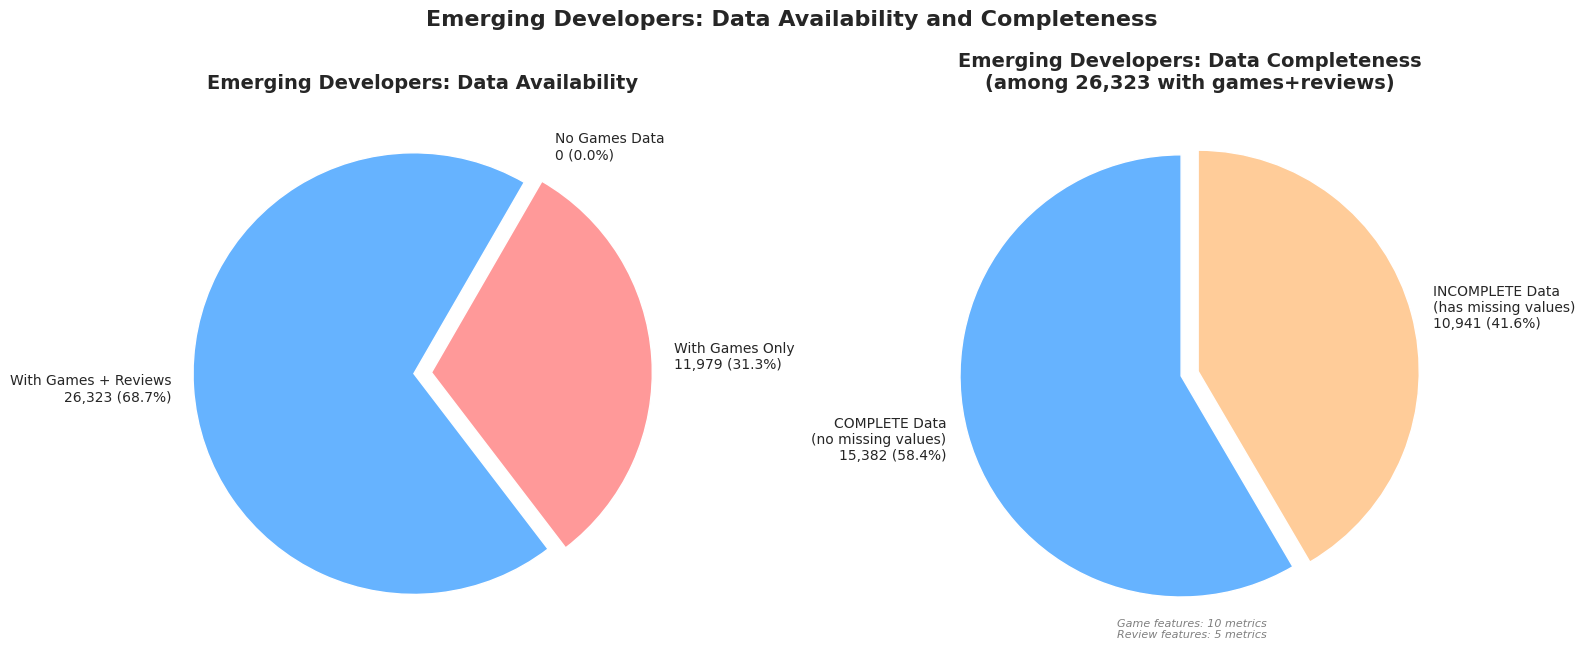


SUMMARY: EMERGING DEVELOPERS DATA STATUS
Category                                        Count   Percentage
------------------------------------------------------------------
Total Emerging Developers                      38,302       100.0%
  With Games + Reviews                         26,323        68.7%
    → COMPLETE data                            15,382        40.2%
    → INCOMPLETE data                          10,941        28.6%
  With Games Only                              11,979        31.3%
  No Games Data                                     0         0.0%


In [119]:
# Cell: Data availability and completeness in emerging developers

# Get all emerging developer IDs
emerging_ids = set(df_emerging_devs['developer_id'])
total_emerging = len(emerging_ids)

devs_with_games = set(df_game_dev['developer_id'].unique())

# --- PART 1: Data Availability ---

# Developers with games AND reviews
emerging_with_both = emerging_ids.intersection(devs_with_reviews)

# Developers with games ONLY (no reviews)
emerging_games_only = emerging_ids.intersection(devs_with_games) - devs_with_reviews

# Developers with NO games (and therefore no reviews)
emerging_no_games = emerging_ids - devs_with_games

print("\nDATA AVAILABILITY:")
print(f"Total emerging developers: {total_emerging:,}")
print(f"  • With games AND reviews: {len(emerging_with_both):,} ({len(emerging_with_both)/total_emerging*100:.1f}%)")
print(f"  • With games ONLY (no reviews): {len(emerging_games_only):,} ({len(emerging_games_only)/total_emerging*100:.1f}%)")
print(f"  • With NO games data: {len(emerging_no_games):,} ({len(emerging_no_games)/total_emerging*100:.1f}%)")

# Create availability pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Data Availability
colors_avail = ['#66b3ff', '#ff9999', '#c2c2f0']
sizes_avail = [len(emerging_with_both), len(emerging_games_only), len(emerging_no_games)]
labels_avail = [
    f'With Games + Reviews\n{len(emerging_with_both):,} ({len(emerging_with_both)/total_emerging*100:.1f}%)',
    f'With Games Only\n{len(emerging_games_only):,} ({len(emerging_games_only)/total_emerging*100:.1f}%)',
    f'No Games Data\n{len(emerging_no_games):,} ({len(emerging_no_games)/total_emerging*100:.1f}%)'
]
explode_avail = (0.05, 0.03, 0.08)

ax1.pie(sizes_avail, labels=labels_avail, colors=colors_avail, explode=explode_avail,
        startangle=60, wedgeprops={'edgecolor': 'white', 'linewidth': 1},
        textprops={'fontsize': 10})
ax1.set_title('Emerging Developers: Data Availability', fontsize=14, fontweight='bold')
ax1.axis('equal')

# --- PART 2: Data Completeness (among those with both games and reviews) ---

# Define game feature columns to check for completeness
game_feature_cols = ['avg_initial_price', 'percent_free', 'avg_extra_platform_support',
                     'avg_achievement_count', 'genre_count', 'avg_discount_percent',
                     'category_count', 'years_past_first_release', 'release_frequency',
                     'avg_languages']

# Define review feature columns to check for completeness  
review_feature_cols = [
    'weighted_vote_score_mean', 'avg_review_count',
    'author_playtime_forever_mean', 'author_num_games_owned_mean',
    'author_num_reviews_mean'
]

# Get developers with both games and reviews
emerging_with_both_list = list(emerging_with_both)

if len(emerging_with_both_list) > 0:
    # Filter dev_stats for these developers
    emerging_both_stats = dev_stats[dev_stats['developer_id'].isin(emerging_with_both_list)].copy()
    
    # Check game data completeness (no NaN in game feature columns)
    emerging_both_stats['game_complete'] = ~emerging_both_stats[game_feature_cols].isna().any(axis=1)
    
    # For review data, we need to merge with review_stats
    # Assuming you have a review_stats DataFrame with per-developer review metrics
    if 'review_stats' in locals():
        emerging_both_reviews = review_stats[review_stats['developer_id'].isin(emerging_with_both_list)].copy()
        
        # Check review data completeness (no NaN in review feature columns that exist)
        available_review_cols = [col for col in review_feature_cols if col in review_stats.columns]
        if available_review_cols:
            emerging_both_reviews['review_complete'] = ~emerging_both_reviews[available_review_cols].isna().any(axis=1)
        else:
            # If no review stats, assume all have review data (they have reviews by definition)
            emerging_both_reviews['review_complete'] = True
    else:
        # If no review_stats, create simple completeness based on presence in review data
        # All developers in emerging_with_both have reviews by definition
        emerging_both_stats['review_complete'] = True
    
    # Merge completeness info
    if 'review_stats' in locals() and available_review_cols:
        completeness = pd.merge(
            emerging_both_stats[['developer_id', 'game_complete']],
            emerging_both_reviews[['developer_id', 'review_complete']],
            on='developer_id', how='left'
        ).fillna({'review_complete': False})
    else:
        completeness = emerging_both_stats[['developer_id', 'game_complete']].copy()
        completeness['review_complete'] = True
    
    # Categorize
    fully_complete = completeness[completeness['game_complete'] & completeness['review_complete']]['developer_id'].nunique()
    incomplete = len(emerging_with_both) - fully_complete
    
    print(f"\nDATA COMPLETENESS (among {len(emerging_with_both):,} developers with both games+reviews):")
    print(f"  • COMPLETE data (no missing values): {fully_complete:,} ({fully_complete/len(emerging_with_both)*100:.1f}%)")
    print(f"  • INCOMPLETE data (has missing values): {incomplete:,} ({incomplete/len(emerging_with_both)*100:.1f}%)")
    
    # Create completeness pie chart
    colors_comp = ['#66b3ff', '#ffcc99']
    sizes_comp = [fully_complete, incomplete]
    labels_comp = [
        f'COMPLETE Data\n(no missing values)\n{fully_complete:,} ({fully_complete/len(emerging_with_both)*100:.1f}%)',
        f'INCOMPLETE Data\n(has missing values)\n{incomplete:,} ({incomplete/len(emerging_with_both)*100:.1f}%)'
    ]
    explode_comp = (0.05, 0.03)
    
    ax2.pie(sizes_comp, labels=labels_comp, colors=colors_comp, explode=explode_comp,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1},
            textprops={'fontsize': 10})
    ax2.set_title(f'Emerging Developers: Data Completeness\n(among {len(emerging_with_both):,} with games+reviews)', 
                  fontsize=14, fontweight='bold')
    
    # Add note about which features were checked
    feature_note = f"Game features: {len(game_feature_cols)} metrics\nReview features: {len(review_feature_cols)} metrics"
    ax2.text(0, -1.2, feature_note, ha='center', fontsize=8, style='italic', color='gray')
    
else:
    ax2.text(0.5, 0.5, 'No developers with both\ngames and reviews', 
             ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Emerging Developers: Data Completeness', fontsize=14, fontweight='bold')

ax2.axis('equal')

plt.suptitle('Emerging Developers: Data Availability and Completeness', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\n" + "=" * 70)
print("SUMMARY: EMERGING DEVELOPERS DATA STATUS")
print("=" * 70)
print(f"{'Category':<40} {'Count':>12} {'Percentage':>12}")
print("-" * 66)
print(f"{'Total Emerging Developers':<40} {total_emerging:>12,} {100.0:>11.1f}%")
print(f"{'  With Games + Reviews':<40} {len(emerging_with_both):>12,} {len(emerging_with_both)/total_emerging*100:>11.1f}%")
print(f"{'    → COMPLETE data':<40} {fully_complete if len(emerging_with_both)>0 else 0:>12,} {fully_complete/total_emerging*100 if len(emerging_with_both)>0 else 0:>11.1f}%")
print(f"{'    → INCOMPLETE data':<40} {incomplete if len(emerging_with_both)>0 else 0:>12,} {incomplete/total_emerging*100 if len(emerging_with_both)>0 else 0:>11.1f}%")
print(f"{'  With Games Only':<40} {len(emerging_games_only):>12,} {len(emerging_games_only)/total_emerging*100:>11.1f}%")
print(f"{'  No Games Data':<40} {len(emerging_no_games):>12,} {len(emerging_no_games)/total_emerging*100:>11.1f}%")
print("=" * 70)